# MCU Model Performance Analysis

This notebook visualizes the performance of deployed LIF models on MCU, showing the relationship between maximum inference frequency and angular error.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the data
data = {
    'Model': [
        'baseline', 'layers', 'channels', 'channels', 'channels', 'input resolution', 'input resolution', 'input resolution',
    ],
    'Specs': [
        '32ch., 256x256, 8l., rec.', '6 layers', '16ch.', '8ch.', '4ch.', '128x128', '64x64', '32x32',
    ],
    'N. Operations [M ops.]': [7380, 4951, 1878, 486, 129, 1845, 461, 115],
    'AEE [pixels]': [2.7, 2.9, 2.9, 3.2, 3.4, 2.76, 2.9, 2.93],
    'AAE [degrees]': [24, 29, 30, 42, 60, 44, 62, 73],
    'Static Memory Allocation [MB]': [76, 59, 38, 19, 10, 19, 5, 1]
}

df = pd.DataFrame(data)
print("Data loaded successfully:")
print(df)

Data loaded successfully:
              Model                      Specs  N. Operations [M ops.]  \
0          baseline  32ch., 256x256, 8l., rec.                    7380   
1            layers                   6 layers                    4951   
2          channels                      16ch.                    1878   
3          channels                       8ch.                     486   
4          channels                       4ch.                     129   
5  input resolution                    128x128                    1845   
6  input resolution                      64x64                     461   
7  input resolution                      32x32                     115   

   AEE [pixels]  AAE [degrees]  Static Memory Allocation [MB]  
0          2.70             24                             76  
1          2.90             29                             59  
2          2.90             30                             38  
3          3.20             42                     

In [8]:
FULL_DATASET_old = {
    'Model': [
        '8L 256x256 32CH', '8L 256x256 16CH', '8L 256x256 8CH', '8L 256x256 4CH', '8L 128x128 32CH', '8L 128x128 16CH', '8L 128x128 8CH', '8L 128x128 4CH',
        '8L 64x64 32CH', '8L 64x64 16CH', '8L 64x64 8CH', '8L 64x64 4CH', '8L 32x32 32CH', '8L 32x32 16CH', '8L 32x32 8CH', '8L 32x32 4CH',
        '6L 256x256 32CH', '6L 256x256 16CH', '6L 256x256 8CH', '6L 256x256 4CH', '6L 128x128 32CH', '6L 128x128 16CH', '6L 128x128 8CH', '6L 128x128 4CH',
        '6L 64x64 32CH', '6L 64x64 16CH', '6L 64x64 8CH', '6L 64x64 4CH', '6L 32x32 32CH', '6L 32x32 16CH', '6L 32x32 8CH', '6L 32x32 4CH'
    ],
    'N. ops [M MAC]': [7350, 1863, 479, 126, 1838, 466, 120, 31, 459, 116, 30, 8, 115, 29, 7, 2,
                               4930, 1257, 327, 88, 1233, 314, 82, 22, 308, 79, 20, 5, 77, 20, 5, 1],
    'Max Throughput [Hz] at 370 MHz': [None, None, 0.4, 0.2, 0.1, 0.3, 1.7, 0.9, 0.5, 1.6, 7.5, 9.7, 2.4, 13, 43.6, 70.1,
                                       None, None, 0.5, 0.3, 0.2, 0.4, 2.2, 1.2, 0.8, 2.3, 10.1, 13.9, 3.4, 19.1, 62, 97.7],
    'Runtime [M cycles]': [None, None, 983, 1821, 3239, 1207, 223, 410, 706, 224, 49, 38, 155, 28, 8, 5,
                           None, None, 751, 1313, 2293, 869, 170, 296, 490, 159, 36, 26, 107, 19, 5, 3],
    'AEE [pixels]': [2.7, 2.91, 3.21, 3.44, 2.44, 2.74, 3, 3.12, 2.68, 2.97, 3.03, 3.15, 2.79, 3.04, 3.06, 3.16,
                     2.86, 2.84, 3.37, 3.72, 2.8, 2.59, 3.04, 3.3, 3.12, 2.85, 3.07, 3.23, 3.25, 3.01, 3.05, 3.22],
    'AAE [degrees]': [24, 29, 41, 60, 30, 39, 57, 65, 49, 57, 70, 78, 65, 71, 81, 89,
                      29, 27, 54, 76, 41, 33, 62, 77, 63, 51, 76, 84, 79, 69, 83, 89],
    'Static Memory Allocation [MB]': [76.8, 38.8, 19.9, 10.5, 19.4, 9.8, 5, 2.6, 5, 2.5, 1.3, 0.7, 1.4, 0.7, 0.3, 0.2,
                                      59.9, 30.4, 15.7, 8.4, 15.1, 7.6, 3.9, 2.1, 3.9, 1.9, 1, 0.5, 1.1, 0.5, 0.2, 0.1],
    'Dynamic Memory Allocation [MB]': [75.5, 37.7, 18.9, 9.4, 18.9, 9.4, 4.7, 2.3, 4.7, 2.3, 1.2, 0.6, 1.2, 0.6, 0.3, 0.1,
                                       58.7, 29.4, 14.7, 7.3, 14.7, 7.3, 3.7, 1.8, 3.7, 1.8, 0.9, 0.5, 0.9, 0.5, 0.2, 0.1]
}

df_full_old = pd.DataFrame(FULL_DATASET_old)
print("Data loaded successfully:")
print(df_full_old)

Data loaded successfully:
              Model  N. ops [M MAC]  Max Throughput [Hz] at 370 MHz  \
0   8L 256x256 32CH            7350                             NaN   
1   8L 256x256 16CH            1863                             NaN   
2    8L 256x256 8CH             479                             0.4   
3    8L 256x256 4CH             126                             0.2   
4   8L 128x128 32CH            1838                             0.1   
5   8L 128x128 16CH             466                             0.3   
6    8L 128x128 8CH             120                             1.7   
7    8L 128x128 4CH              31                             0.9   
8     8L 64x64 32CH             459                             0.5   
9     8L 64x64 16CH             116                             1.6   
10     8L 64x64 8CH              30                             7.5   
11     8L 64x64 4CH               8                             9.7   
12    8L 32x32 32CH             115                

In [2]:
FULL_DATASET = {
    'Model': [
        '8L 256x256 32CH', '8L 256x256 16CH', '8L 256x256 8CH', '8L 256x256 4CH', '8L 128x128 32CH', '8L 128x128 16CH', '8L 128x128 8CH', '8L 128x128 4CH',
        '8L 64x64 32CH', '8L 64x64 16CH', '8L 64x64 8CH', '8L 64x64 4CH', '8L 32x32 32CH', '8L 32x32 16CH', '8L 32x32 8CH', '8L 32x32 4CH',
        '6L 256x256 32CH', '6L 256x256 16CH', '6L 256x256 8CH', '6L 256x256 4CH', '6L 128x128 32CH', '6L 128x128 16CH', '6L 128x128 8CH', '6L 128x128 4CH',
        '6L 64x64 32CH', '6L 64x64 16CH', '6L 64x64 8CH', '6L 64x64 4CH', '6L 32x32 32CH', '6L 32x32 16CH', '6L 32x32 8CH', '6L 32x32 4CH'
    ],
    'N. ops [M MAC]': [7350, 1863, 479, 126, 1838, 466, 120, 31, 459, 116, 30, 8, 115, 29, 7, 2,
                               4930, 1257, 327, 88, 1233, 314, 82, 22, 308, 79, 20, 5, 77, 20, 5, 1],
    'Max Throughput [Hz] at 370 MHz': [None, None, 0.4, 0.2, 0.1, 0.3, 1.7, 0.9, 0.5, 1.6, 7.5, 9.7, 2.4, 13, 43.6, 70.1,
                                       None, None, 0.5, 0.3, 0.2, 0.4, 2.2, 1.2, 0.8, 2.3, 10.1, 13.9, 3.4, 19.1, 62, 97.7],
    'Runtime [M cycles]': [None, None, 983, 1821, 3239, 1207, 223, 410, 706, 224, 49, 38, 155, 28, 8, 5,
                           None, None, 751, 1313, 2293, 869, 170, 296, 490, 159, 36, 26, 107, 19, 5, 3],
    'AEE [pixels]': [2.7, 2.9, 3.2, 3.4, 2.8, 3.1, 3.4, 3.5, 3.2, 3.5, 3.6, 3.6, 3.5, 3.7, 3.8, 3.8, 
                     2.9, 2.8, 3.4, 3.7, 3.1, 3.0, 3.4, 3.7, 3.6, 3.4, 3.6, 3.8, 3.9, 3.7, 3.8, 3.9],
    'AAE [degrees]': [23.6, 29.4, 41.5, 60.0, 27.8, 37.0, 54.7, 62.3, 45.1, 55.2, 67.3, 72.0, 60.4, 69.6, 79.3, 83.7, 
                      28.8, 27.5, 53.6, 75.5, 38.9, 30.9, 59.2, 74.4, 59.3, 47.8, 73.3, 78.8, 74.9, 64.8, 82.6, 84.6],
    'Static Memory Allocation [MB]': [76.8, 38.8, 19.9, 10.5, 19.4, 9.8, 5, 2.6, 5, 2.5, 1.3, 0.7, 1.4, 0.7, 0.3, 0.2,
                                      59.9, 30.4, 15.7, 8.4, 15.1, 7.6, 3.9, 2.1, 3.9, 1.9, 1, 0.5, 1.1, 0.5, 0.2, 0.1],
    'Dynamic Memory Allocation [MB]': [75.5, 37.7, 18.9, 9.4, 18.9, 9.4, 4.7, 2.3, 4.7, 2.3, 1.2, 0.6, 1.2, 0.6, 0.3, 0.1,
                                       58.7, 29.4, 14.7, 7.3, 14.7, 7.3, 3.7, 1.8, 3.7, 1.8, 0.9, 0.5, 0.9, 0.5, 0.2, 0.1]
}

df_full = pd.DataFrame(FULL_DATASET)
print("Data loaded successfully:")
print(df_full)

Data loaded successfully:
              Model  N. ops [M MAC]  Max Throughput [Hz] at 370 MHz  \
0   8L 256x256 32CH            7350                             NaN   
1   8L 256x256 16CH            1863                             NaN   
2    8L 256x256 8CH             479                             0.4   
3    8L 256x256 4CH             126                             0.2   
4   8L 128x128 32CH            1838                             0.1   
5   8L 128x128 16CH             466                             0.3   
6    8L 128x128 8CH             120                             1.7   
7    8L 128x128 4CH              31                             0.9   
8     8L 64x64 32CH             459                             0.5   
9     8L 64x64 16CH             116                             1.6   
10     8L 64x64 8CH              30                             7.5   
11     8L 64x64 4CH               8                             9.7   
12    8L 32x32 32CH             115                

In [7]:
# MEM. ALLOCATION IS TEMPORARY, ONLY CALCULATED /4 FOR INT8 MODELS

FULL_DATASET_int8_old = {
    'Model': [
        '8L 256x256 32CH', '8L 256x256 16CH', '8L 256x256 8CH', '8L 256x256 4CH', '8L 128x128 32CH', '8L 128x128 16CH', '8L 128x128 8CH', '8L 128x128 4CH',
        '8L 64x64 32CH', '8L 64x64 16CH', '8L 64x64 8CH', '8L 64x64 4CH', '8L 32x32 32CH', '8L 32x32 16CH', '8L 32x32 8CH', '8L 32x32 4CH',
        '6L 256x256 32CH', '6L 256x256 16CH', '6L 256x256 8CH', '6L 256x256 4CH', '6L 128x128 32CH', '6L 128x128 16CH', '6L 128x128 8CH', '6L 128x128 4CH',
        '6L 64x64 32CH', '6L 64x64 16CH', '6L 64x64 8CH', '6L 64x64 4CH', '6L 32x32 32CH', '6L 32x32 16CH', '6L 32x32 8CH', '6L 32x32 4CH'
    ],
    'N. ops [M MAC]': [7389, 1883, 489, 131, 1847, 471, 122, 33, 462, 118, 30, 8, 115, 29, 8, 2,
                         4960, 1272, 334, 92, 1240, 318, 84, 23, 310, 79, 21, 6, 77, 20, 5, 1],
    'Max Throughput [Hz] at 370 MHz': [None, 0.2, 1.1, 0.9, 0.6, 1.3, 5.1, 8.2, 2.8, 17.9, 30.7, 36.5, 40.8, 82.2, 119.9, 142.6,
                                       None, 0.3, 1.2, 1.1, 0.8, 1.7, 5.8, 9, 3.7, 23, 33.7, 38.6, 52.6, 95.8, 131.7, 151.5],
    'Runtime [M cycles]': [None, 1736, 338, 412, 627, 289, 73, 44, 133, 20, 12, 10, 9, 4, 3, 2,
                           None, 1339, 310, 347, 473, 223, 63, 41, 99, 16, 10, 9, 7, 3, 2, 2],
    'AEE [pixels]': [2.75, 2.91, 3.26, 3.5, 2.5, 2.73, 3.01, 3.16, 2.7, 3, 3.01, 3.19, 2.78, 3.01, 3, 3.16,
                     2.9, 2.94, 3.32, 3.7, 2.62, 2.71, 2.98, 3.29, 2.73, 2.99, 3.03, 3.23, 2.83, 2.97, 3, 3.2],
    'AAE [degrees]': [23, 28, 45, 63, 31, 36, 58, 68, 49, 56, 70, 81, 66, 68, 79, 88,
                      32, 34, 49, 75, 37, 38, 56, 77, 55, 55, 72, 85, 75, 65, 81, 91],
    'Static Memory Allocation [MB]': [20, 10.5, 5.8, 3.4, 5, 2.6, 1.4, 0.8, 1.3, 0.7, 0.4, 0.2, 0.4, 0.2, 0.1, 0.05,
                                      15.8, 8.4, 4.7, 2.9, 4, 2.1, 1.2, 0.7, 1, 0.5, 0.3, 0.2, 0.3, 0.1, 0.1, 0.05],
    'Dynamic Memory Allocation [MB]': [18.9, 9.4, 4.7, 2.4, 4.7, 2.4, 1.2, 0.6, 1.2, 0.6, 0.3, 0.1, 0.3, 0.1, 0.07, 0.04,
                                       16.8, 8.4, 4.2, 2.1, 4.2, 2.1, 1, 0.5, 1, 0.5, 0.3, 0.1, 0.3, 0.1, 0.06, 0.03]
}

df_full_int8_old = pd.DataFrame(FULL_DATASET_int8_old)
print("Data loaded successfully:")
print(df_full_int8_old)

Data loaded successfully:
              Model  N. ops [M MAC]  Max Throughput [Hz] at 370 MHz  \
0   8L 256x256 32CH            7389                             NaN   
1   8L 256x256 16CH            1883                             0.2   
2    8L 256x256 8CH             489                             1.1   
3    8L 256x256 4CH             131                             0.9   
4   8L 128x128 32CH            1847                             0.6   
5   8L 128x128 16CH             471                             1.3   
6    8L 128x128 8CH             122                             5.1   
7    8L 128x128 4CH              33                             8.2   
8     8L 64x64 32CH             462                             2.8   
9     8L 64x64 16CH             118                            17.9   
10     8L 64x64 8CH              30                            30.7   
11     8L 64x64 4CH               8                            36.5   
12    8L 32x32 32CH             115                

In [3]:
# MEM. ALLOCATION IS TEMPORARY, ONLY CALCULATED /4 FOR INT8 MODELS

FULL_DATASET_int8 = {
    'Model': [
        '8L 256x256 32CH', '8L 256x256 16CH', '8L 256x256 8CH', '8L 256x256 4CH', '8L 128x128 32CH', '8L 128x128 16CH', '8L 128x128 8CH', '8L 128x128 4CH',
        '8L 64x64 32CH', '8L 64x64 16CH', '8L 64x64 8CH', '8L 64x64 4CH', '8L 32x32 32CH', '8L 32x32 16CH', '8L 32x32 8CH', '8L 32x32 4CH',
        '6L 256x256 32CH', '6L 256x256 16CH', '6L 256x256 8CH', '6L 256x256 4CH', '6L 128x128 32CH', '6L 128x128 16CH', '6L 128x128 8CH', '6L 128x128 4CH',
        '6L 64x64 32CH', '6L 64x64 16CH', '6L 64x64 8CH', '6L 64x64 4CH', '6L 32x32 32CH', '6L 32x32 16CH', '6L 32x32 8CH', '6L 32x32 4CH'
    ],
    'N. ops [M MAC]': [7389, 1883, 489, 131, 1847, 471, 122, 33, 462, 118, 30, 8, 115, 29, 8, 2,
                         4960, 1272, 334, 92, 1240, 318, 84, 23, 310, 79, 21, 6, 77, 20, 5, 1],
    'Max Throughput [Hz] at 370 MHz': [None, 0.2, 1.1, 0.9, 0.6, 1.3, 5.1, 8.2, 2.8, 17.9, 30.7, 36.5, 40.8, 82.2, 119.9, 142.6,
                                       None, 0.3, 1.2, 1.1, 0.8, 1.7, 5.8, 9, 3.7, 23, 33.7, 38.6, 52.6, 95.8, 131.7, 151.5],
    'Runtime [M cycles]': [None, 1736, 338, 412, 627, 289, 73, 44, 133, 20, 12, 10, 9, 4, 3, 2,
                           None, 1339, 310, 347, 473, 223, 63, 41, 99, 16, 10, 9, 7, 3, 2, 2],
    'AEE [pixels]': [2.7, 2.9, 3.3, 3.5, 2.9, 3.1, 3.4, 3.5, 3.2, 3.5, 3.6, 3.7, 3.5, 3.7, 3.7, 3.8,
                     2.9, 2.9, 3.3, 3.7, 3.0, 3.1, 3.4, 3.7, 3.3, 3.5, 3.6, 3.8, 3.6, 3.6, 3.7, 3.9],
    'AAE [degrees]': [23.3, 27.7, 44.8, 63.3, 28.7, 34.8, 55.8, 65.0, 44.2, 54.1, 67.0, 76.0, 61.9, 65.5, 76.8, 83.0,
                      31.6, 33.9, 49.4, 74.9, 33.8, 36.0, 53.6, 74.2, 48.9, 52.1, 69.4, 79.9, 69.4, 59.4, 81.4, 86.7],
    'Static Memory Allocation [MB]': [20, 10.5, 5.8, 3.4, 5, 2.6, 1.4, 0.8, 1.3, 0.7, 0.4, 0.2, 0.4, 0.2, 0.1, 0.05,
                                      15.8, 8.4, 4.7, 2.9, 4, 2.1, 1.2, 0.7, 1, 0.5, 0.3, 0.2, 0.3, 0.1, 0.1, 0.05],
    'Dynamic Memory Allocation [MB]': [18.9, 9.4, 4.7, 2.4, 4.7, 2.4, 1.2, 0.6, 1.2, 0.6, 0.3, 0.1, 0.3, 0.1, 0.07, 0.04,
                                       16.8, 8.4, 4.2, 2.1, 4.2, 2.1, 1, 0.5, 1, 0.5, 0.3, 0.1, 0.3, 0.1, 0.06, 0.03]
}

df_full_int8 = pd.DataFrame(FULL_DATASET_int8)
print("Data loaded successfully:")
print(df_full_int8)

Data loaded successfully:
              Model  N. ops [M MAC]  Max Throughput [Hz] at 370 MHz  \
0   8L 256x256 32CH            7389                             NaN   
1   8L 256x256 16CH            1883                             0.2   
2    8L 256x256 8CH             489                             1.1   
3    8L 256x256 4CH             131                             0.9   
4   8L 128x128 32CH            1847                             0.6   
5   8L 128x128 16CH             471                             1.3   
6    8L 128x128 8CH             122                             5.1   
7    8L 128x128 4CH              33                             8.2   
8     8L 64x64 32CH             462                             2.8   
9     8L 64x64 16CH             118                            17.9   
10     8L 64x64 8CH              30                            30.7   
11     8L 64x64 4CH               8                            36.5   
12    8L 32x32 32CH             115                

/tmp/ipykernel_17547/1820046690.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


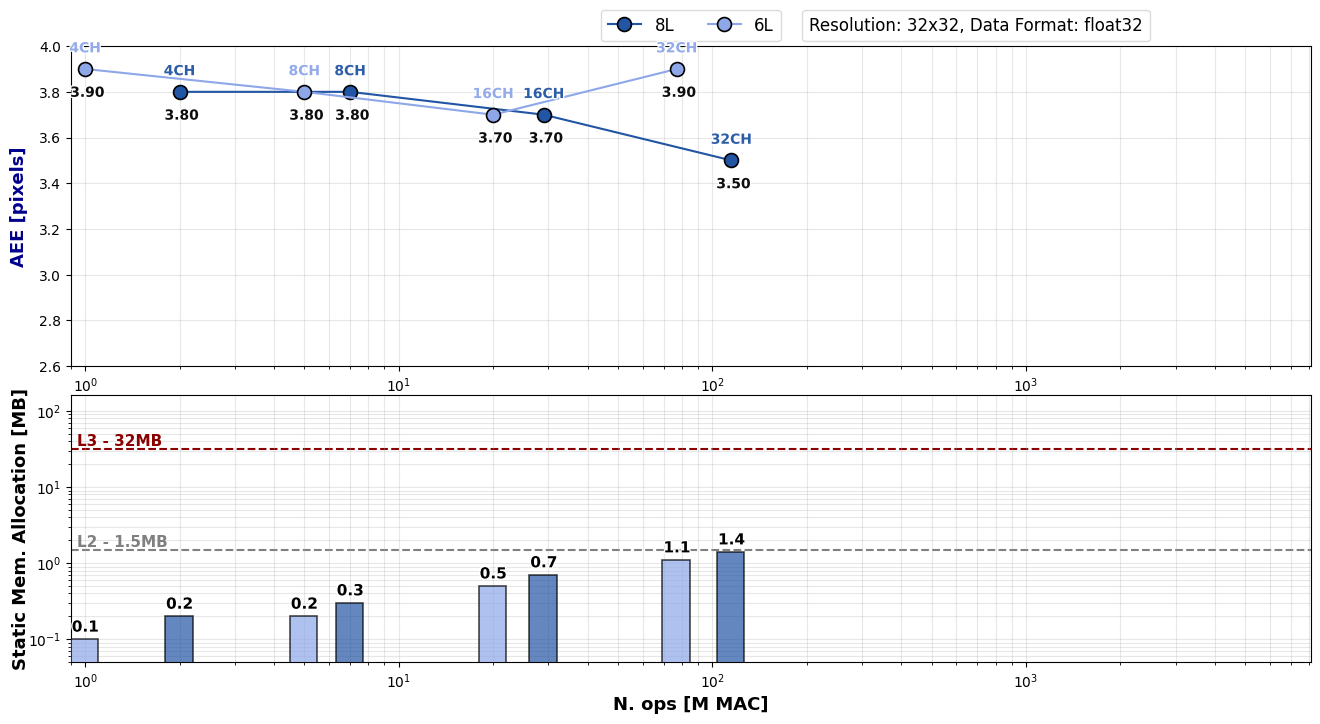

Resolution: 32x32
Total layer groups: 2
8L: 4 models (channels: [4, 8, 16, 32])
6L: 4 models (channels: [4, 8, 16, 32])


In [32]:
# CURVES BASED ON SPECIFIC MODELS BASED ON INPUT RESOLUTION:
# Only RES resolution - 2 curves: 8L and 6L with channel variation

import matplotlib.lines as mlines
from matplotlib.patheffects import withStroke
import matplotlib.patches as mpatches

RES = '32x32' # Input resolution to filter
y_axis = 'AEE [pixels]' # AEE [pixels] or AAE [degrees]
x_axis = 'N. ops [M MAC]'  # N. ops [M MAC] or Runtime [M cycles] or Max Throughput [Hz] at 370 MHz
data_type = 'float32'  # 'float32' or 'int8'

# Filter out rows with None Runtime values and exclude baseline
if data_type == 'float32':
    df_filtered = df_full[(df_full[x_axis].notna()) & (df_full['Model'] != 'baseline')].copy()
else:
    df_filtered = df_full_int8[(df_full_int8[x_axis].notna()) & (df_full_int8['Model'] != 'baseline')].copy()

# Extract layer type, channel, and resolution information
df_filtered['Layer_Type'] = df_filtered['Model'].str.extract(r'^(6L|8L)\b')[0]
df_filtered['Channels'] = df_filtered['Model'].str.extract(r'(\d+)CH')[0].astype(int)
df_filtered['Resolution'] = df_filtered['Model'].str.extract(r'(\d+x\d+)')[0]

# Filter for 256x256 resolution only
df_filtered = df_filtered[df_filtered['Resolution'] == RES].copy()

# Create labels showing channel count
df_filtered['Label'] = df_filtered['Channels'].astype(str) + 'CH'

# Group by layer type only (8L and 6L)
layer_groups = {}
for layer_type in ['8L', '6L']:
    group_data = df_filtered[df_filtered['Layer_Type'] == layer_type].copy()
    if len(group_data) > 0:
        layer_groups[layer_type] = group_data

# Create figure with two vertically stacked subplots
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, 
                                gridspec_kw={'height_ratios': [0.6, 0.5], 'hspace': 0.1})
ax1.set_facecolor('none')
ax3.set_facecolor('none')
fig.patch.set_alpha(0.0)

# Define colors for the two layer types

if data_type == 'float32' and y_axis == 'AEE [pixels]':
    colors = {
        '8L': '#2255a3',  
        '6L': '#8EA7E9'   
    }
elif data_type == 'int8' and y_axis == 'AAE [degrees]':
    colors = {
        '8L': '#42ab49',  
        '6L': '#bddeb3'   
    }
elif data_type == 'int8' and y_axis == 'AEE [pixels]':
    colors = {
        '8L': "#9daeff",  
        '6L': '#d7e3fc'   
    }
elif data_type == 'float32' and y_axis == 'AAE [degrees]':
    colors = {
        '8L': '#495d49',    
        '6L': '#9cbb89'    
    }

# ===== TOP PLOT: AAE vs MACs =====
if x_axis == 'Max Throughput [Hz] at 370 MHz':
    ax1.set_xlim(0.08, 155)
    ax1.set_xscale('log')
elif x_axis == 'Runtime [M cycles]':
    ax1.set_xlim(min(df_filtered[x_axis]) * 0.5, max(df_filtered[x_axis]) * 1.2)
elif x_axis == 'N. ops [M MAC]':
    ax1.set_xlim(0.9, 8100)
    ax1.set_xscale('log')
    
if y_axis == 'AEE [pixels]':
    ax1.set_ylim(2.6, 4)
    ax1.set_ylabel(y_axis, fontsize=13, fontweight='bold', labelpad=8, color='DarkBlue')
elif y_axis == 'AAE [degrees]':
    ax1.set_ylim(20, 95)
    ax1.set_ylabel(y_axis, fontsize=13, fontweight='bold', labelpad=8, color='DarkGreen')
ax1.grid(True, alpha=0.3, which='both')
ax1.tick_params(axis='x', which='both', labelbottom=True)

# Plot curves for each layer type
for layer_type, df_group in layer_groups.items():
    # Sort by MACs (which corresponds to sorting by channels)
    df_group_sorted = df_group.sort_values(x_axis)
    
    # Plot line
    ax1.plot(df_group_sorted[x_axis], df_group_sorted[y_axis], 
            linestyle='-', color=colors[layer_type], linewidth=1.5, label=f'{layer_type}', 
            marker='o', markersize=10, markeredgecolor='black', markeredgewidth=1.2, zorder=3)
    
    # Add labels for each point showing channel count
    for idx, row in df_group_sorted.iterrows():
        # Add 'baseline' to the label for 8L 32CH
        if layer_type == '8L' and row['Channels'] == 32 and row['Resolution'] == "256x256":
            label_text = f"{row['Label']}\nbaseline"
        else:
            label_text = f"{row['Label']}"
    
        # First annotation: colored label (channel count and baseline)
        ax1.annotate(label_text, 
                    (row[x_axis], row[y_axis]), 
                    textcoords="offset points", xytext=(0, 12), ha='center', 
                    fontsize=10, color=colors[layer_type], fontweight='bold', alpha=0.95, zorder=11,
                    path_effects=[withStroke(linewidth=2, foreground='white')])
    
        # Second annotation: black Error value below the colored label
        if y_axis == 'AEE [pixels]':
            ax1.annotate(f"{row[y_axis]:.2f}", 
                        (row[x_axis], row[y_axis]), 
                        textcoords="offset points", xytext=(1.5, -20), ha='center', 
                        fontsize=10, color='black', fontweight='bold', alpha=0.95, zorder=11,
                        path_effects=[withStroke(linewidth=2, foreground='white')])
        elif y_axis == 'AAE [degrees]': 
            ax1.annotate(f"{row[y_axis]:.0f}°", 
                        (row[x_axis], row[y_axis]), 
                        textcoords="offset points", xytext=(1.5, -20), ha='center', 
                        fontsize=10, color='black', fontweight='bold', alpha=0.95, zorder=11,
                        path_effects=[withStroke(linewidth=2, foreground='white')])

# Create two separate legends
# First legend: Model variations with colors
legend1 = ax1.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=2, 
                    frameon=True, fancybox=True, shadow=False, 
                    facecolor='white', edgecolor='lightgray', framealpha=0.8)

# Second legend: Resolution and Data info
resolution_patch = mpatches.Patch(color='none', label=f'Resolution: {RES}, Data Format: {data_type}')
legend2 = ax1.legend(handles=[resolution_patch], fontsize=12, loc='upper center', 
                    bbox_to_anchor=(0.73, 1.14), ncol=1,
                    frameon=True, fancybox=True, shadow=False, 
                    facecolor='white', edgecolor='lightgray', framealpha=0.8,
                    handlelength=0, handletextpad=0)

# Add the first legend back (matplotlib removes it when creating the second)
ax1.add_artist(legend1)

# ===== BOTTOM PLOT: Memory Allocation vs MACs =====
ax3.set_xlabel(x_axis, fontsize=13, fontweight='bold')
ax3.set_ylabel('Static Mem. Allocation [MB]', fontsize=13, fontweight='bold', labelpad=-1)
ax3.set_yscale('log')
ax3.set_ylim(0.05, 160)
ax3.grid(True, alpha=0.3, which='both')
if x_axis == 'Max Throughput [Hz] at 370 MHz':
    ax3.set_xlim(0.08, 155)
    ax3.set_xscale('log')
elif x_axis == 'Runtime [M cycles]':
    ax3.set_xlim(min(df_filtered[x_axis]) * 0.5, max(df_filtered[x_axis]) * 1.2)
elif x_axis == 'N. ops [M MAC]':
    ax3.set_xlim(0.9, 8100)
    ax3.set_xscale('log')

# Plot memory bars for each layer type
bar_width_factor = 0.20

for layer_type, df_group in layer_groups.items():
    for idx, row in df_group.iterrows():
        if x_axis == 'N. ops [M MAC]':
            bar_width = row[x_axis] * bar_width_factor
        elif x_axis == 'Runtime [M cycles]':
            bar_width = (max(df_filtered[x_axis]) * 1.2 - min(df_filtered[x_axis]) * 0.5) * bar_width_factor / 10
        elif x_axis == 'Max Throughput [Hz] at 370 MHz':
            bar_width = row[x_axis] * bar_width_factor
        ax3.bar(row[x_axis], 
               row['Static Memory Allocation [MB]'],
               width=bar_width, color=colors[layer_type], alpha=0.7, align='center', 
               zorder=5, edgecolor='black', linewidth=1.2)
        # Add label on top of each bar showing the MB value
        ax3.text(row[x_axis], 
                row['Static Memory Allocation [MB]'] * 1.15,
                f"{row['Static Memory Allocation [MB]']:.2g}",
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', zorder=10,
                path_effects=[withStroke(linewidth=2, foreground='white')])

# Add horizontal lines for static memory allocation (L2 and L3)
ax3.axhline(y=1.5, color='gray', linestyle='--', linewidth=1.5, zorder=1)
ax3.axhline(y=32, color='darkred', linestyle='--', linewidth=1.5, zorder=1)
ax3.text(ax3.get_xlim()[0] * 1.05, 1.5, 'L2 - 1.5MB', color='gray', fontsize=11, fontweight='bold', 
         verticalalignment='bottom', horizontalalignment='left')
ax3.text(ax3.get_xlim()[0] * 1.05, 32, 'L3 - 32MB', color='darkred', fontsize=11, fontweight='bold', 
         verticalalignment='bottom', horizontalalignment='left')

fig.tight_layout()
plt.show()

# Print summary
print(f"Resolution: {RES}")
print(f"Total layer groups: {len(layer_groups)}")
for layer_type, df_group in layer_groups.items():
    print(f"{layer_type}: {len(df_group)} models (channels: {sorted(df_group['Channels'].tolist())})")

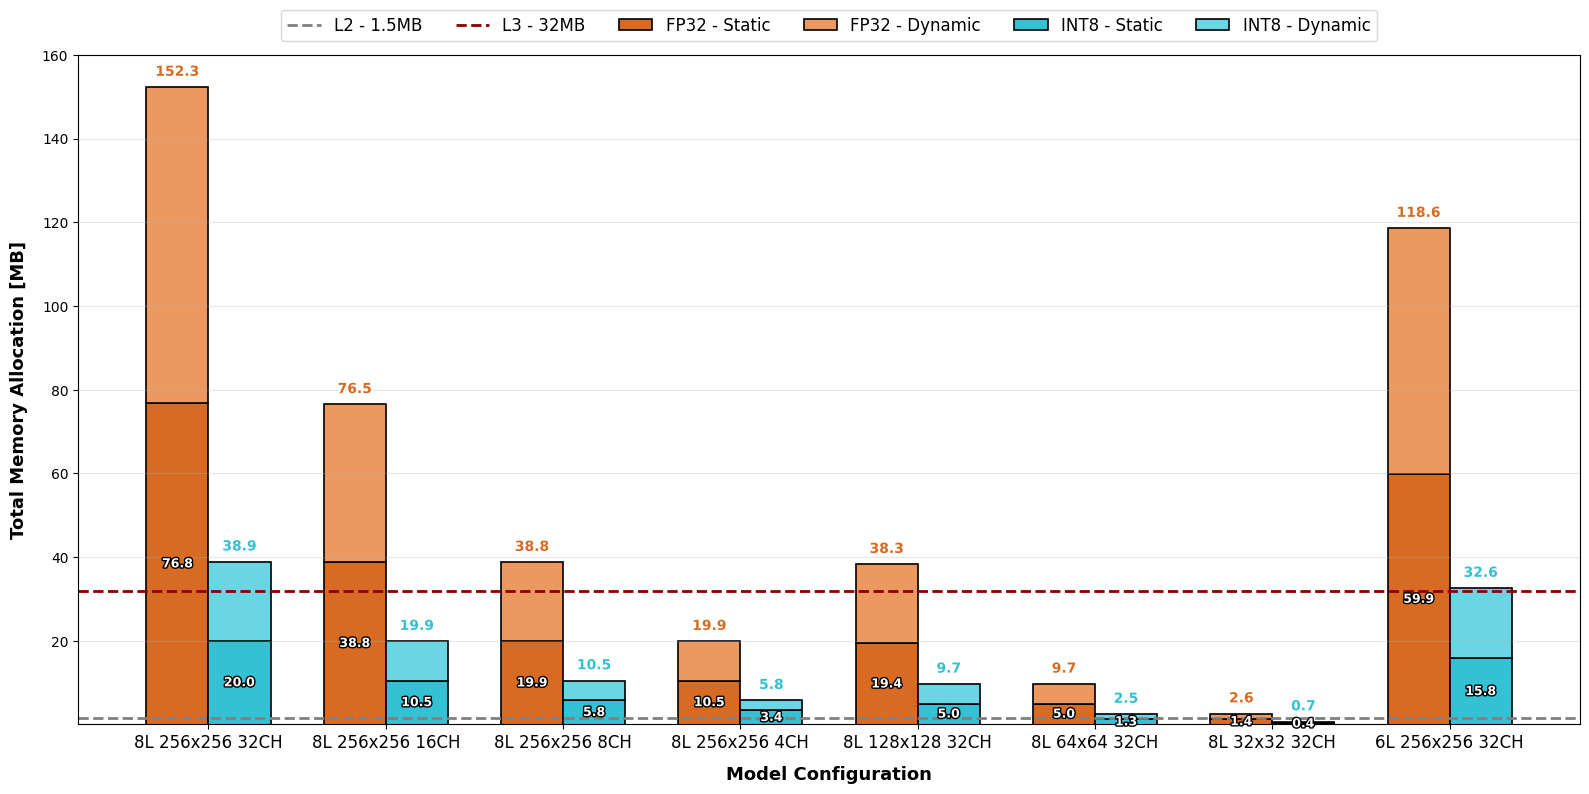


Memory Allocation Summary:
8L 256x256 32CH      | FP32:  152.3 MB | INT8:   38.9 MB | Reduction:  74.5%
8L 256x256 16CH      | FP32:   76.5 MB | INT8:   19.9 MB | Reduction:  74.0%
8L 256x256 8CH       | FP32:   38.8 MB | INT8:   10.5 MB | Reduction:  72.9%
8L 256x256 4CH       | FP32:   19.9 MB | INT8:    5.8 MB | Reduction:  70.9%
8L 128x128 32CH      | FP32:   38.3 MB | INT8:    9.7 MB | Reduction:  74.7%
8L 64x64 32CH        | FP32:    9.7 MB | INT8:    2.5 MB | Reduction:  74.2%
8L 32x32 32CH        | FP32:    2.6 MB | INT8:    0.7 MB | Reduction:  73.1%
6L 256x256 32CH      | FP32:  118.6 MB | INT8:   32.6 MB | Reduction:  72.5%


In [4]:
# Memory Allocation Comparison: FP32 vs INT8 for Selected Models
# Stacked bar chart showing static + dynamic memory allocation

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patheffects import withStroke

# Define the 8 models to compare
selected_models = [
    '8L 256x256 32CH',
    '8L 256x256 16CH', 
    '8L 256x256 8CH',
    '8L 256x256 4CH',
    '8L 128x128 32CH',
    '8L 64x64 32CH',
    '8L 32x32 32CH',
    '6L 256x256 32CH'
]

# Extract data for these models from both datasets
fp32_data = []
int8_data = []

for model in selected_models:
    # Get FP32 data
    fp32_row = df_full[df_full['Model'] == model]
    if not fp32_row.empty:
        fp32_data.append({
            'model': model,
            'static': fp32_row['Static Memory Allocation [MB]'].values[0],
            'dynamic': fp32_row['Dynamic Memory Allocation [MB]'].values[0]
        })
    
    # Get INT8 data
    int8_row = df_full_int8[df_full_int8['Model'] == model]
    if not int8_row.empty:
        int8_data.append({
            'model': model,
            'static': int8_row['Static Memory Allocation [MB]'].values[0],
            'dynamic': int8_row['Dynamic Memory Allocation [MB]'].values[0]
        })

# Create the plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_facecolor('none')
fig.patch.set_alpha(0.0)

# Set up positions for grouped bars
x = np.arange(len(selected_models))
width = 0.35  # Width of each bar

# Colors for FP32 and INT8
color_fp32_static = "#D86B23"
color_fp32_dynamic = "#EC9861"
color_int8_static = "#34C1D3"
color_int8_dynamic = "#6AD6E4"

# Plot FP32 bars (stacked: static on bottom, dynamic on top)
fp32_static = [d['static'] for d in fp32_data]
fp32_dynamic = [d['dynamic'] for d in fp32_data]

bars_fp32_static = ax.bar(x - width/2, fp32_static, width, 
                           label='FP32 - Static', color=color_fp32_static, 
                           edgecolor='black', linewidth=1.2)
bars_fp32_dynamic = ax.bar(x - width/2, fp32_dynamic, width, 
                            bottom=fp32_static, label='FP32 - Dynamic', 
                            color=color_fp32_dynamic, edgecolor='black', linewidth=1.2)

# Plot INT8 bars (stacked: static on bottom, dynamic on top)
int8_static = [d['static'] for d in int8_data]
int8_dynamic = [d['dynamic'] for d in int8_data]

bars_int8_static = ax.bar(x + width/2, int8_static, width, 
                           label='INT8 - Static', color=color_int8_static, 
                           edgecolor='black', linewidth=1.2)
bars_int8_dynamic = ax.bar(x + width/2, int8_dynamic, width, 
                            bottom=int8_static, label='INT8 - Dynamic', 
                            color=color_int8_dynamic, edgecolor='black', linewidth=1.2)

# Add static memory values in the middle of the static portion of each bar
for i in range(len(selected_models)):
    # FP32 static value
    ax.text(i - width/2, fp32_static[i] / 2, f'{fp32_static[i]:.1f}', 
            ha='center', va='center', fontsize=9, fontweight='bold', 
            color='white', path_effects=[withStroke(linewidth=2, foreground='black')])
    
    # INT8 static value
    ax.text(i + width/2, int8_static[i] / 2, f'{int8_static[i]:.1f}', 
            ha='center', va='center', fontsize=9, fontweight='bold', 
            color='white', path_effects=[withStroke(linewidth=2, foreground='black')])
    
# Add total values on top of each bar
for i in range(len(selected_models)):
    # FP32 total
    fp32_total = fp32_static[i] + fp32_dynamic[i]
    ax.text(i - width/2, fp32_total + 2, f'{fp32_total:.1f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', 
            color=color_fp32_static, path_effects=[withStroke(linewidth=2, foreground='white')])
    
    # INT8 total
    int8_total = int8_static[i] + int8_dynamic[i]
    ax.text(i + width/2, int8_total + 2, f'{int8_total:.1f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', 
            color=color_int8_static, path_effects=[withStroke(linewidth=2, foreground='white')])

# Add horizontal lines for L2 and L3 memory limits
ax.axhline(y=1.5, color='gray', linestyle='--', linewidth=2, zorder=1, label='L2 - 1.5MB')
ax.axhline(y=32, color='darkred', linestyle='--', linewidth=2, zorder=1, label='L3 - 32MB')

# Labels and formatting
ax.set_xlabel('Model Configuration', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Total Memory Allocation [MB]', fontsize=13, fontweight='bold', labelpad=10)
#ax.set_title('Memory Allocation Comparison: FP32 vs INT8\n(Static + Dynamic Memory)', 
#             fontsize=15, fontweight='bold', pad=20)

# Set x-axis labels
ax.set_xticks(x)
ax.set_xticklabels(selected_models, rotation=0, ha='center', fontsize=12)

# Set y-axis limits for better visualization
ax.set_ylim(0.05, 160)

# Grid
ax.grid(True, alpha=0.3, which='both', axis='y')

# Legend
ax.legend(fontsize=12, loc='upper center', frameon=True, fancybox=True, 
          shadow=False, facecolor='white', edgecolor='lightgray', framealpha=0.9,
          ncol=6, bbox_to_anchor=(0.5, 1.08))

fig.tight_layout()
plt.show()

# Print summary
print("\nMemory Allocation Summary:")
print("=" * 80)
for i, model in enumerate(selected_models):
    fp32_total = fp32_static[i] + fp32_dynamic[i]
    int8_total = int8_static[i] + int8_dynamic[i]
    reduction = ((fp32_total - int8_total) / fp32_total) * 100
    print(f"{model:20s} | FP32: {fp32_total:6.1f} MB | INT8: {int8_total:6.1f} MB | Reduction: {reduction:5.1f}%")

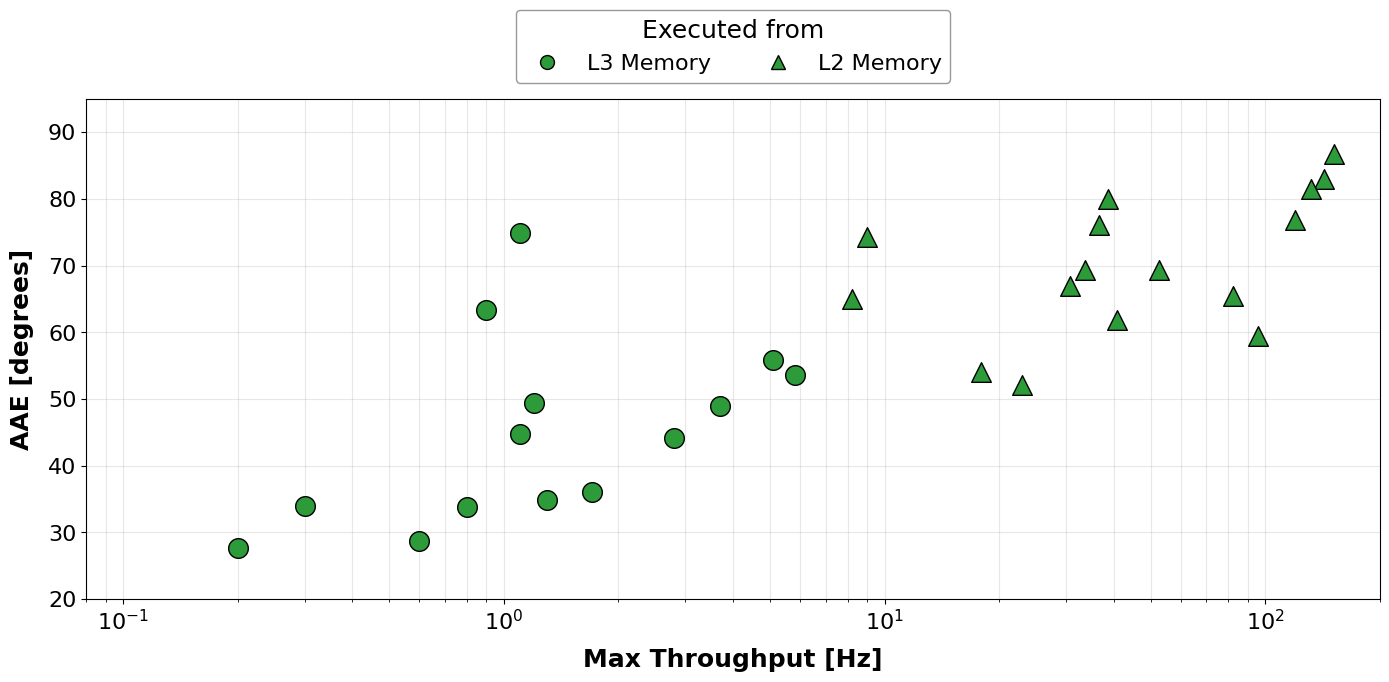


Total INT8 models plotted: 30
  - L3 memory: 14
  - L2 memory: 16

Models per resolution:
  256x256: 6 INT8
  128x128: 8 INT8
  64x64: 8 INT8
  32x32: 8 INT8


In [5]:
# Max Throughput vs AAE - Combined FP32 and INT8
# Scatter plot with different markers for memory allocation and colors for data types

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patheffects import withStroke
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Define which models run from L2 (triangles) and L3 (squares)
l2_models_int8 = [
    '8L 128x128 4CH', '8L 64x64 16CH', '8L 64x64 8CH', '8L 64x64 4CH',
    '8L 32x32 32CH', '8L 32x32 16CH', '8L 32x32 8CH', '8L 32x32 4CH',
    '6L 128x128 4CH', '6L 64x64 16CH', '6L 64x64 8CH', '6L 64x64 4CH',
    '6L 32x32 32CH', '6L 32x32 16CH', '6L 32x32 8CH', '6L 32x32 4CH'
]

# Use only INT8 dataset
df_int8 = df_full_int8.copy()
df_int8['DataType'] = 'INT8'
df_int8['L2Model'] = df_int8['Model'].isin(l2_models_int8)

# Filter out rows with None values for the metrics we need
df_filtered = df_int8[(df_int8['AAE [degrees]'].notna()) & 
                      (df_int8['Max Throughput [Hz] at 370 MHz'].notna())].copy()

# Extract resolution information
df_filtered['Resolution'] = df_filtered['Model'].str.extract(r'(\d+x\d+)')[0]

# Define color for INT8
color_int8 = '#2D9B3A'  # Green for the new dataset
#color_int8 = "#87DA90"  # Green for the old dataset

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('none')
fig.patch.set_alpha(0.0)

# INT8 L3 models (circles, green)
df_int8_l3 = df_filtered[~df_filtered['L2Model']]
if len(df_int8_l3) > 0:
    ax.scatter(df_int8_l3['Max Throughput [Hz] at 370 MHz'],
              df_int8_l3['AAE [degrees]'],
              color=color_int8,
              s=200, 
              marker='o',
              edgecolor='black',
              linewidth=1,
              zorder=3,
              alpha=1)

# INT8 L2 models (triangles, green)
df_int8_l2 = df_filtered[df_filtered['L2Model']]
if len(df_int8_l2) > 0:
    ax.scatter(df_int8_l2['Max Throughput [Hz] at 370 MHz'],
              df_int8_l2['AAE [degrees]'],
              color=color_int8,
              s=200, 
              marker='^',
              edgecolor='black',
              linewidth=1,
              zorder=3,
              alpha=1)

# Create custom legend handles for memory allocation (L2 vs L3)
legend_memory = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=color_int8, markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='L3 Memory'),
    Line2D([0], [0], marker='^', color='w', 
           markerfacecolor=color_int8, markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='L2 Memory')
]

# Labels and formatting
ax.set_xlabel('Max Throughput [Hz]', fontsize=18, fontweight='bold', labelpad=10)
ax.set_ylabel('AAE [degrees]', fontsize=18, fontweight='bold', labelpad=10)

# Set log scale for x-axis
ax.set_xscale('log')

# Set appropriate limits
ax.set_xlim(0.08, 200)
ax.set_ylim(20, 95)

# Grid
ax.grid(True, alpha=0.3, which='both')

# Tick labels
ax.tick_params(axis='both', labelsize=16)

# Legend: Memory allocation
legend1 = ax.legend(handles=legend_memory, fontsize=16, loc='upper center',
                    title='Executed from', title_fontsize=18,
                    frameon=True, fancybox=True, shadow=False, 
                    facecolor='white', edgecolor='#999999', framealpha=1,
                    bbox_to_anchor=(0.5, 1.2), ncol=2)

fig.tight_layout()
plt.show()

# Print summary
print(f"\nTotal INT8 models plotted: {len(df_filtered)}")
print(f"  - L3 memory: {len(df_filtered[~df_filtered['L2Model']])}")
print(f"  - L2 memory: {len(df_filtered[df_filtered['L2Model']])}")
print("\nModels per resolution:")
for resolution in ['256x256', '128x128', '64x64', '32x32']:
    int8_count = len(df_filtered[df_filtered['Resolution'] == resolution])
    print(f"  {resolution}: {int8_count} INT8")

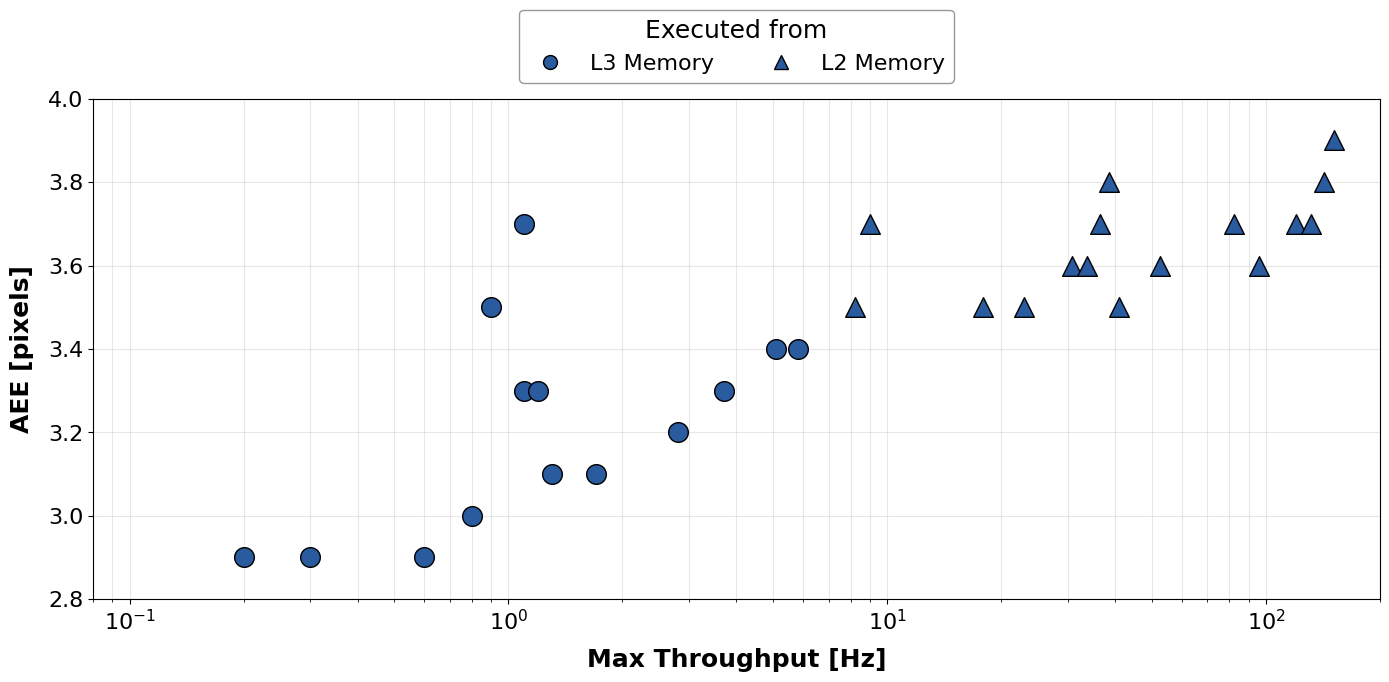


Total INT8 models plotted: 30
  - L3 memory: 14
  - L2 memory: 16

Models per resolution:
  256x256: 6 INT8
  128x128: 8 INT8
  64x64: 8 INT8
  32x32: 8 INT8


In [6]:
# Max Throughput vs AEE - Combined FP32 and INT8
# Scatter plot with different markers for memory allocation and colors for data types

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patheffects import withStroke
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Define which models run from L2 (triangles) and L3 (squares)
l2_models_int8 = [
    '8L 128x128 4CH', '8L 64x64 16CH', '8L 64x64 8CH', '8L 64x64 4CH',
    '8L 32x32 32CH', '8L 32x32 16CH', '8L 32x32 8CH', '8L 32x32 4CH',
    '6L 128x128 4CH', '6L 64x64 16CH', '6L 64x64 8CH', '6L 64x64 4CH',
    '6L 32x32 32CH', '6L 32x32 16CH', '6L 32x32 8CH', '6L 32x32 4CH'
]

# Use only INT8 dataset
df_int8 = df_full_int8.copy()
df_int8['DataType'] = 'INT8'
df_int8['L2Model'] = df_int8['Model'].isin(l2_models_int8)

# Filter out rows with None values for the metrics we need
df_filtered = df_int8[(df_int8['AEE [pixels]'].notna()) & 
                      (df_int8['Max Throughput [Hz] at 370 MHz'].notna())].copy()

# Extract resolution information
df_filtered['Resolution'] = df_filtered['Model'].str.extract(r'(\d+x\d+)')[0]

# Define color for INT8
color_int8 = "#295B9E"  # Blue for the new dataset
#color_int8 = "#5D84B7"  # Blue for the old dataset

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('none')
fig.patch.set_alpha(0.0)

# INT8 L3 models (circles, blue)
df_int8_l3 = df_filtered[~df_filtered['L2Model']]
if len(df_int8_l3) > 0:
    ax.scatter(df_int8_l3['Max Throughput [Hz] at 370 MHz'],
              df_int8_l3['AEE [pixels]'],
              color=color_int8,
              s=200, 
              marker='o',
              edgecolor='black',
              linewidth=1,
              zorder=3,
              alpha=1)

# INT8 L2 models (triangles, blue)
df_int8_l2 = df_filtered[df_filtered['L2Model']]
if len(df_int8_l2) > 0:
    ax.scatter(df_int8_l2['Max Throughput [Hz] at 370 MHz'],
              df_int8_l2['AEE [pixels]'],
              color=color_int8,
              s=200, 
              marker='^',
              edgecolor='black',
              linewidth=1,
              zorder=3,
              alpha=1)

# Create custom legend handles for memory allocation (L2 vs L3)
legend_memory = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=color_int8, markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='L3 Memory'),
    Line2D([0], [0], marker='^', color='w', 
           markerfacecolor=color_int8, markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='L2 Memory')
]

# Labels and formatting
ax.set_xlabel('Max Throughput [Hz]', fontsize=18, fontweight='bold', labelpad=10)
ax.set_ylabel('AEE [pixels]', fontsize=18, fontweight='bold', labelpad=10)

# Set log scale for x-axis
ax.set_xscale('log')

# Set appropriate limits
ax.set_xlim(0.08, 200)
ax.set_ylim(2.8, 4.0)

# Grid
ax.grid(True, alpha=0.3, which='both')

# Tick labels
ax.tick_params(axis='both', labelsize=16)

# Legend: Memory allocation
legend1 = ax.legend(handles=legend_memory, fontsize=16, loc='upper center',
                    title='Executed from', title_fontsize=18,
                    frameon=True, fancybox=True, shadow=False, 
                    facecolor='white', edgecolor='#999999', framealpha=1,
                    bbox_to_anchor=(0.5, 1.2), ncol=2)

fig.tight_layout()
plt.show()

# Print summary
print(f"\nTotal INT8 models plotted: {len(df_filtered)}")
print(f"  - L3 memory: {len(df_filtered[~df_filtered['L2Model']])}")
print(f"  - L2 memory: {len(df_filtered[df_filtered['L2Model']])}")
print("\nModels per resolution:")
for resolution in ['256x256', '128x128', '64x64', '32x32']:
    int8_count = len(df_filtered[df_filtered['Resolution'] == resolution])
    print(f"  {resolution}: {int8_count} INT8")

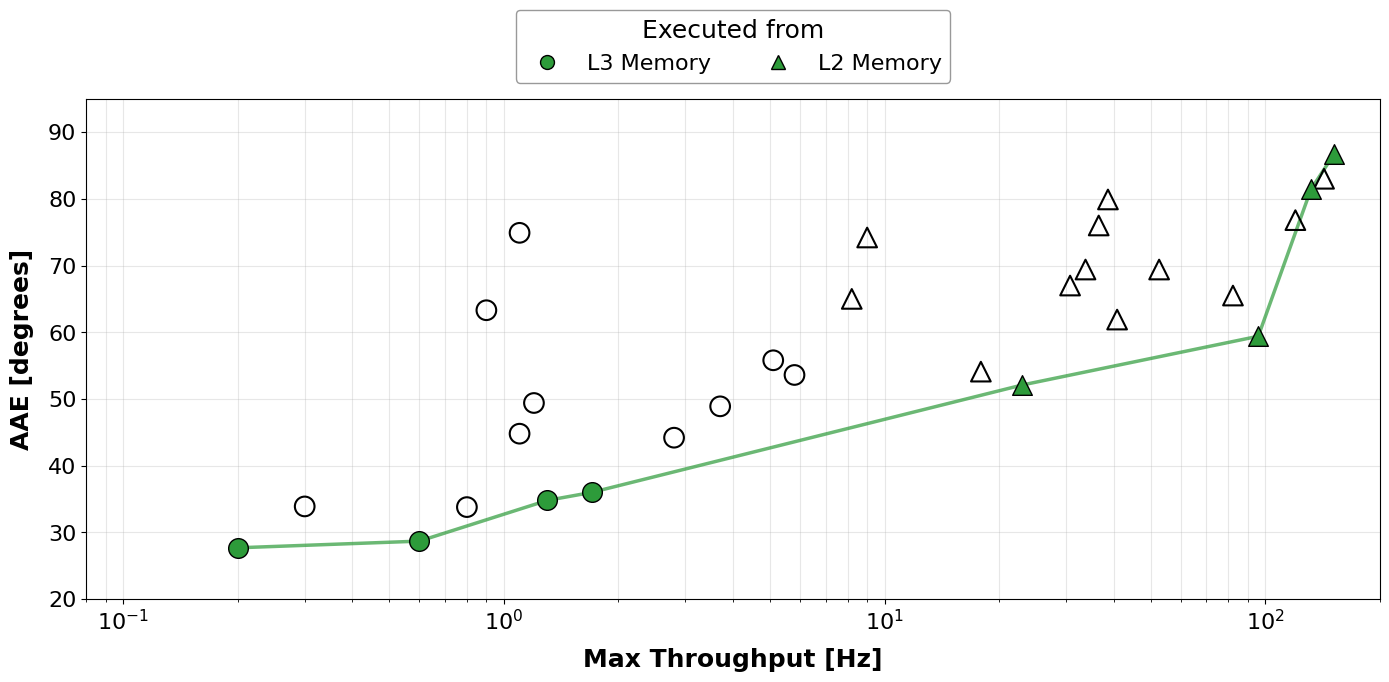


Total INT8 models plotted: 30
  - L3 memory: 14
  - L2 memory: 16
  - Pareto frontier: 8

Pareto frontier models:
  8L 256x256 16CH: 0.2 Hz, 28°
  8L 128x128 32CH: 0.6 Hz, 29°
  8L 128x128 16CH: 1.3 Hz, 35°
  6L 128x128 16CH: 1.7 Hz, 36°
  6L 64x64 16CH: 23.0 Hz, 52°
  6L 32x32 16CH: 95.8 Hz, 59°
  6L 32x32 8CH: 131.7 Hz, 81°
  6L 32x32 4CH: 151.5 Hz, 87°

Models per resolution:
  256x256: 6 INT8
  128x128: 8 INT8
  64x64: 8 INT8
  32x32: 8 INT8


In [7]:
# Max Throughput vs AAE - Combined FP32 and INT8
# Scatter plot with different markers for memory allocation and colors for data types

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patheffects import withStroke
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Define which models run from L2 (triangles) and L3 (squares)
l2_models_int8 = [
    '8L 128x128 4CH', '8L 64x64 16CH', '8L 64x64 8CH', '8L 64x64 4CH',
    '8L 32x32 32CH', '8L 32x32 16CH', '8L 32x32 8CH', '8L 32x32 4CH',
    '6L 128x128 4CH', '6L 64x64 16CH', '6L 64x64 8CH', '6L 64x64 4CH',
    '6L 32x32 32CH', '6L 32x32 16CH', '6L 32x32 8CH', '6L 32x32 4CH'
]

# Define Pareto-optimal models (models on the Pareto frontier)
# These should be filled and connected with a line
# Lower AAE and higher throughput is better
pareto_models = [
    '8L 256x256 16CH',  # Example - adjust based on your actual Pareto curve
    '8L 128x128 32CH',
    '8L 128x128 16CH',
    '6L 128x128 16CH',
    '6L 64x64 16CH',
    '6L 32x32 16CH',
    '6L 32x32 8CH',
    '6L 32x32 4CH'
]

# Use only INT8 dataset
df_int8 = df_full_int8.copy()
df_int8['DataType'] = 'INT8'
df_int8['L2Model'] = df_int8['Model'].isin(l2_models_int8)
df_int8['IsPareto'] = df_int8['Model'].isin(pareto_models)

# Filter out rows with None values for the metrics we need
df_filtered = df_int8[(df_int8['AAE [degrees]'].notna()) & 
                      (df_int8['Max Throughput [Hz] at 370 MHz'].notna())].copy()

# Extract resolution information
df_filtered['Resolution'] = df_filtered['Model'].str.extract(r'(\d+x\d+)')[0]

# Define color for INT8
color_int8 = '#2D9B3A'  # Green

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('none')
fig.patch.set_alpha(0.0)

# INT8 L3 models - empty (not on Pareto frontier)
df_int8_l3_empty = df_filtered[(~df_filtered['L2Model']) & (~df_filtered['IsPareto'])]
if len(df_int8_l3_empty) > 0:
    ax.scatter(df_int8_l3_empty['Max Throughput [Hz] at 370 MHz'],
              df_int8_l3_empty['AAE [degrees]'],
              facecolors='none',
              edgecolors='black',
              s=200, 
              marker='o',
              linewidth=1.5,
              zorder=3,
              alpha=1)

# INT8 L3 models - filled (on Pareto frontier)
df_int8_l3_filled = df_filtered[(~df_filtered['L2Model']) & (df_filtered['IsPareto'])]
if len(df_int8_l3_filled) > 0:
    ax.scatter(df_int8_l3_filled['Max Throughput [Hz] at 370 MHz'],
              df_int8_l3_filled['AAE [degrees]'],
              color=color_int8,
              s=200, 
              marker='o',
              edgecolor='black',
              linewidth=1,
              zorder=4,
              alpha=1)

# INT8 L2 models - empty (not on Pareto frontier)
df_int8_l2_empty = df_filtered[(df_filtered['L2Model']) & (~df_filtered['IsPareto'])]
if len(df_int8_l2_empty) > 0:
    ax.scatter(df_int8_l2_empty['Max Throughput [Hz] at 370 MHz'],
              df_int8_l2_empty['AAE [degrees]'],
              facecolors='none',
              edgecolors='black',
              s=200, 
              marker='^',
              linewidth=1.5,
              zorder=3,
              alpha=1)

# INT8 L2 models - filled (on Pareto frontier)
df_int8_l2_filled = df_filtered[(df_filtered['L2Model']) & (df_filtered['IsPareto'])]
if len(df_int8_l2_filled) > 0:
    ax.scatter(df_int8_l2_filled['Max Throughput [Hz] at 370 MHz'],
              df_int8_l2_filled['AAE [degrees]'],
              color=color_int8,
              s=200, 
              marker='^',
              edgecolor='black',
              linewidth=1,
              zorder=4,
              alpha=1)

# Draw Pareto frontier line connecting filled models
df_pareto = df_filtered[df_filtered['IsPareto']].copy()
if len(df_pareto) > 0:
    # Sort by throughput (x-axis) for proper line connection
    df_pareto_sorted = df_pareto.sort_values('Max Throughput [Hz] at 370 MHz')
    ax.plot(df_pareto_sorted['Max Throughput [Hz] at 370 MHz'],
           df_pareto_sorted['AAE [degrees]'],
           color=color_int8,
           linewidth=2.5,
           linestyle='-',
           zorder=2,
           alpha=0.7,
           label='Pareto frontier')

# Create custom legend handles for memory allocation (L2 vs L3)
legend_memory = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=color_int8, markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='L3 Memory'),
    Line2D([0], [0], marker='^', color='w', 
           markerfacecolor=color_int8, markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='L2 Memory')
]

# Labels and formatting
ax.set_xlabel('Max Throughput [Hz]', fontsize=18, fontweight='bold', labelpad=10)
ax.set_ylabel('AAE [degrees]', fontsize=18, fontweight='bold', labelpad=10)

# Set log scale for x-axis
ax.set_xscale('log')

# Set appropriate limits
ax.set_xlim(0.08, 200)
ax.set_ylim(20, 95)

# Grid
ax.grid(True, alpha=0.3, which='both')

# Tick labels
ax.tick_params(axis='both', labelsize=16)

# Legend: Memory allocation
legend1 = ax.legend(handles=legend_memory, fontsize=16, loc='upper center',
                    title='Executed from', title_fontsize=18,
                    frameon=True, fancybox=True, shadow=False, 
                    facecolor='white', edgecolor='#999999', framealpha=1,
                    bbox_to_anchor=(0.5, 1.2), ncol=2)

fig.tight_layout()
plt.show()

# Print summary
print(f"\nTotal INT8 models plotted: {len(df_filtered)}")
print(f"  - L3 memory: {len(df_filtered[~df_filtered['L2Model']])}")
print(f"  - L2 memory: {len(df_filtered[df_filtered['L2Model']])}")
print(f"  - Pareto frontier: {len(df_filtered[df_filtered['IsPareto']])}")
print("\nPareto frontier models:")
for _, row in df_pareto_sorted.iterrows():
    print(f"  {row['Model']}: {row['Max Throughput [Hz] at 370 MHz']:.1f} Hz, {row['AAE [degrees]']:.0f}°")
print("\nModels per resolution:")
for resolution in ['256x256', '128x128', '64x64', '32x32']:
    int8_count = len(df_filtered[df_filtered['Resolution'] == resolution])
    print(f"  {resolution}: {int8_count} INT8")

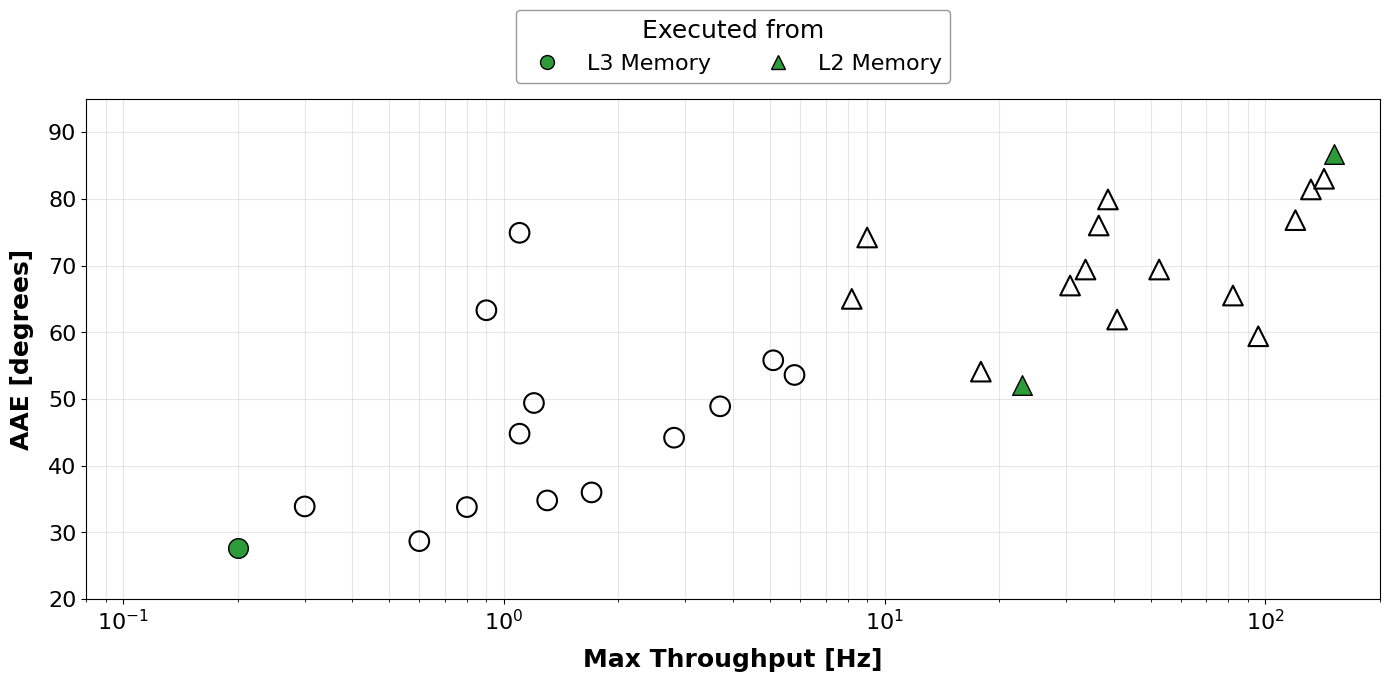


Total INT8 models plotted: 30
  - L3 memory: 14
  - L2 memory: 16
  - Highlighted: 3

Highlighted models:


NameError: name 'df_highlighted' is not defined

In [8]:
# Max Throughput vs AAE - Combined FP32 and INT8
# Scatter plot with different markers for memory allocation and colors for data types

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patheffects import withStroke
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Define which models run from L2 (triangles) and L3 (squares)
l2_models_int8 = [
    '8L 128x128 4CH', '8L 64x64 16CH', '8L 64x64 8CH', '8L 64x64 4CH',
    '8L 32x32 32CH', '8L 32x32 16CH', '8L 32x32 8CH', '8L 32x32 4CH',
    '6L 128x128 4CH', '6L 64x64 16CH', '6L 64x64 8CH', '6L 64x64 4CH',
    '6L 32x32 32CH', '6L 32x32 16CH', '6L 32x32 8CH', '6L 32x32 4CH'
]

# Define the three highlighted models with labels and position
highlighted_models = {
    '8L 256x256 16CH': {
        'label': 'ours - slower\n10.5MB - 0.2Hz\n28° AAE',
        'offset': (0, 20)  # Above the circle - closer
    },
    '6L 32x32 4CH': {
        'label': 'ours - faster\n0.05MB - 151.5Hz\n91° AAE',
        'offset': (0, -30)  # Below the triangle - closer
    },
    '6L 64x64 16CH': {
        'label': 'ours - medium\n0.5MB - 23Hz\n55° AAE',
        'offset': (0, -30)  # Below the triangle - closer
    }
}

# Use only INT8 dataset
df_int8 = df_full_int8.copy()
df_int8['DataType'] = 'INT8'
df_int8['L2Model'] = df_int8['Model'].isin(l2_models_int8)
df_int8['IsHighlighted'] = df_int8['Model'].isin(highlighted_models.keys())

# Filter out rows with None values for the metrics we need
df_filtered = df_int8[(df_int8['AAE [degrees]'].notna()) & 
                      (df_int8['Max Throughput [Hz] at 370 MHz'].notna())].copy()

# Extract resolution information
df_filtered['Resolution'] = df_filtered['Model'].str.extract(r'(\d+x\d+)')[0]

# Define color for INT8
color_int8 = '#2D9B3A'  # Green

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('none')
fig.patch.set_alpha(0.0)

# INT8 L3 models - empty (not highlighted)
df_int8_l3_empty = df_filtered[(~df_filtered['L2Model']) & (~df_filtered['IsHighlighted'])]
if len(df_int8_l3_empty) > 0:
    ax.scatter(df_int8_l3_empty['Max Throughput [Hz] at 370 MHz'],
              df_int8_l3_empty['AAE [degrees]'],
              facecolors='none',
              edgecolors='black',
              s=200, 
              marker='o',
              linewidth=1.5,
              zorder=3,
              alpha=1)

# INT8 L3 models - filled (highlighted)
df_int8_l3_filled = df_filtered[(~df_filtered['L2Model']) & (df_filtered['IsHighlighted'])]
if len(df_int8_l3_filled) > 0:
    ax.scatter(df_int8_l3_filled['Max Throughput [Hz] at 370 MHz'],
              df_int8_l3_filled['AAE [degrees]'],
              color=color_int8,
              s=200, 
              marker='o',
              edgecolor='black',
              linewidth=1,
              zorder=4,
              alpha=1)

# INT8 L2 models - empty (not highlighted)
df_int8_l2_empty = df_filtered[(df_filtered['L2Model']) & (~df_filtered['IsHighlighted'])]
if len(df_int8_l2_empty) > 0:
    ax.scatter(df_int8_l2_empty['Max Throughput [Hz] at 370 MHz'],
              df_int8_l2_empty['AAE [degrees]'],
              facecolors='none',
              edgecolors='black',
              s=200, 
              marker='^',
              linewidth=1.5,
              zorder=3,
              alpha=1)

# INT8 L2 models - filled (highlighted)
df_int8_l2_filled = df_filtered[(df_filtered['L2Model']) & (df_filtered['IsHighlighted'])]
if len(df_int8_l2_filled) > 0:
    ax.scatter(df_int8_l2_filled['Max Throughput [Hz] at 370 MHz'],
              df_int8_l2_filled['AAE [degrees]'],
              color=color_int8,
              s=200, 
              marker='^',
              edgecolor='black',
              linewidth=1,
              zorder=4,
              alpha=1)


# Create custom legend handles for memory allocation (L2 vs L3)
legend_memory = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=color_int8, markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='L3 Memory'),
    Line2D([0], [0], marker='^', color='w', 
           markerfacecolor=color_int8, markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='L2 Memory')
]

# Labels and formatting
ax.set_xlabel('Max Throughput [Hz]', fontsize=18, fontweight='bold', labelpad=10)
ax.set_ylabel('AAE [degrees]', fontsize=18, fontweight='bold', labelpad=10)

# Set log scale for x-axis
ax.set_xscale('log')

# Set appropriate limits
ax.set_xlim(0.08, 200)
ax.set_ylim(20, 95)

# Grid
ax.grid(True, alpha=0.3, which='both')

# Tick labels
ax.tick_params(axis='both', labelsize=16)

# Legend: Memory allocation
legend1 = ax.legend(handles=legend_memory, fontsize=16, loc='upper center',
                    title='Executed from', title_fontsize=18,
                    frameon=True, fancybox=True, shadow=False, 
                    facecolor='white', edgecolor='#999999', framealpha=1,
                    bbox_to_anchor=(0.5, 1.2), ncol=2)

fig.tight_layout()
plt.show()

# Print summary
print(f"\nTotal INT8 models plotted: {len(df_filtered)}")
print(f"  - L3 memory: {len(df_filtered[~df_filtered['L2Model']])}")
print(f"  - L2 memory: {len(df_filtered[df_filtered['L2Model']])}")
print(f"  - Highlighted: {len(df_filtered[df_filtered['IsHighlighted']])}")
print("\nHighlighted models:")
for _, row in df_highlighted.iterrows():
    print(f"  {row['Model']}: {row['Max Throughput [Hz] at 370 MHz']:.1f} Hz, {row['AAE [degrees]']:.0f}°")
print("\nModels per resolution:")
for resolution in ['256x256', '128x128', '64x64', '32x32']:
    int8_count = len(df_filtered[df_filtered['Resolution'] == resolution])
    print(f"  {resolution}: {int8_count} INT8")

/tmp/ipykernel_9098/63001999.py:70: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(0, 8000)
/tmp/ipykernel_9098/63001999.py:112: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax3.set_xlim(0, 8000)
/tmp/ipykernel_9098/63001999.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


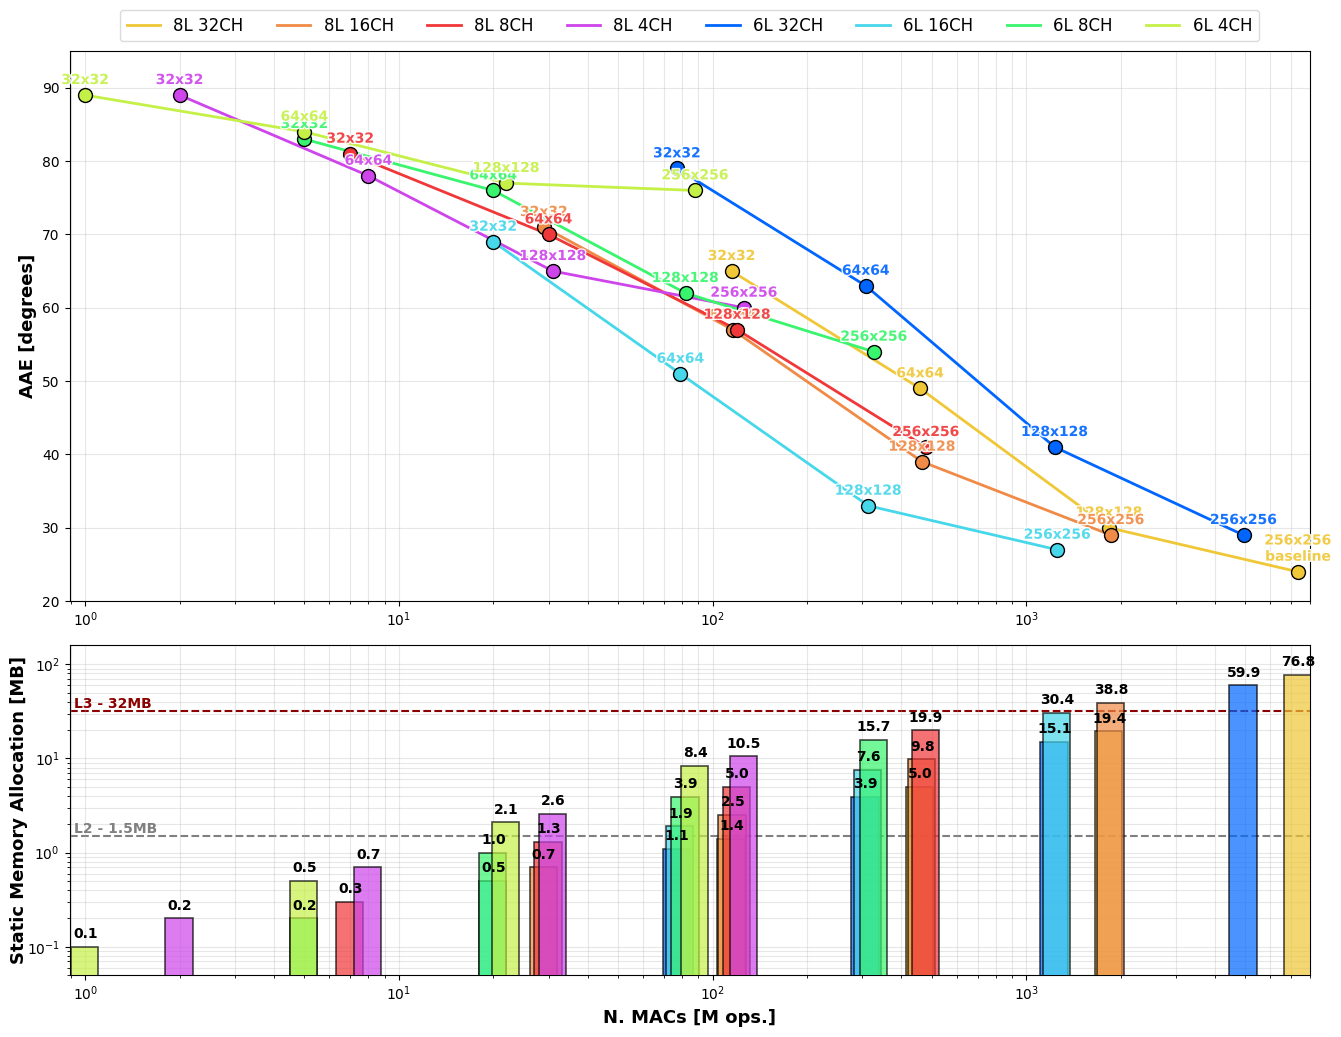

Total groups with data: 8
8L 32CH: 4 points
8L 16CH: 4 points
8L 8CH: 4 points
8L 4CH: 4 points
6L 32CH: 4 points
6L 16CH: 4 points
6L 8CH: 4 points
6L 4CH: 4 points


In [ ]:
# CURVES BASED ON SPECIFIC MODELS BASED ON INPUT RESOLUTION (ANGULAR ERROR):
# 8 curves: FN/FNs with each channel count (32ch, 16ch, 8ch, 4ch) across all resolutions

import matplotlib.lines as mlines
from matplotlib.patheffects import withStroke

data_type = 'float32'  # 'float32' or 'int8'

# Filter out rows with None Runtime values and exclude baseline
if data_type == 'float32':
    df_filtered = df_full[(df_full['N. MACs [M ops.]'].notna()) & (df_full['Model'] != 'baseline')].copy()
else:
    df_filtered = df_full_int8[(df_full_int8['N. MACs [M ops.]'].notna()) & (df_full_int8['Model'] != 'baseline')].copy()

# Extract layer type, channel, and resolution information
# IMPORTANT: Check for 'FNs' first, then 'FN' to avoid misclassification
df_filtered['Layer_Type'] = df_filtered['Model'].str.extract(r'^(6L|8L)\b')[0]
df_filtered['Channels'] = df_filtered['Model'].str.extract(r'(\d+)CH')[0].astype(int)
df_filtered['Resolution'] = df_filtered['Model'].str.extract(r'(\d+x\d+)')[0]

# Create labels showing only resolution (what varies along each curve)
df_filtered['Label'] = df_filtered['Resolution']

# Group by layer type and channel count
layer_channel_groups = {}
for layer_type in ['8L', '6L']:
    for ch in [32, 16, 8, 4]:
        key = f'{layer_type} {ch}CH'
        group_data = df_filtered[
            (df_filtered['Layer_Type'] == layer_type) & 
            (df_filtered['Channels'] == ch)
        ].copy()
        # Only add groups that have data
        if len(group_data) > 0:
            layer_channel_groups[key] = group_data

# Create figure with two vertically stacked subplots
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(16, 12), sharex=True, 
                                gridspec_kw={'height_ratios': [1, 0.6], 'hspace': 0.1})
ax1.set_facecolor('none')
ax3.set_facecolor('none')
fig.patch.set_alpha(0.0)

# Define colors for the eight groups (using a diverse color palette)
colors = {
    '8L 32CH': '#EFC737',    
    '8L 16CH': '#F08B47',   
    '8L 8CH': '#F03739',     
    '8L 4CH': '#CE45EB',     
    '6L 32CH': '#0066FF',   
    '6L 16CH': '#47D7EA',   
    '6L 8CH': '#38F56D',    
    '6L 4CH': '#C5F048'     
}

# Manual label offset dictionary
# Key: (group_name, resolution), Value: (x_offset, y_offset)
label_offsets = {
    # Add your custom offsets here
    # ('group_name', 'resolution'): (x_offset, y_offset)
    
}

def get_label_offset(group_name, resolution):
    return label_offsets.get((group_name, resolution), (0, 8))  # Default offset

# ===== TOP PLOT: AAE vs MACs =====
ax1.set_ylabel('AAE [degrees]', fontsize=13, fontweight='bold')
ax1.set_xscale('log')
ax1.set_xlim(0, 8000)
ax1.set_ylim(20, 95)
ax1.grid(True, alpha=0.3, which='both')
# Show tick labels on top plot x-axis
ax1.tick_params(axis='x', which='both', labelbottom=True)

# Plot curves for each group
for group_name, df_group in layer_channel_groups.items():
    # Sort by MACs
    df_group_sorted = df_group.sort_values('N. MACs [M ops.]')
    
    # Plot line
    ax1.plot(df_group_sorted['N. MACs [M ops.]'], df_group_sorted['AAE [degrees]'], 
            linestyle='-', color=colors[group_name], linewidth=2, label=group_name, zorder=2)
    
    # Plot scatter points
    ax1.scatter(df_group_sorted['N. MACs [M ops.]'], df_group_sorted['AAE [degrees]'], 
               color=colors[group_name], s=100, edgecolor='black', zorder=3)
    
    # Add labels for each point (showing only resolution)
    for idx, row in df_group_sorted.iterrows():
        # Add 'baseline' to the label for 8L 32CH 256x256
        if group_name == '8L 32CH' and row['Label'] == '256x256':
            label_text = f"\nbaseline"
        else:
            label_text = f""
        
        offset_x, offset_y = get_label_offset(group_name, row['Label'])
        ax1.annotate(f"{row['Label']}{label_text}", 
                    (row['N. MACs [M ops.]'], row['AAE [degrees]']), 
                    textcoords="offset points", xytext=(offset_x, offset_y), ha='center', 
                    fontsize=10, color=colors[group_name], fontweight='bold', alpha=0.9, zorder=11,
                    path_effects=[withStroke(linewidth=2, foreground='white')])

legend = ax1.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 1.09), ncol=8, 
                   frameon=True, fancybox=True, shadow=False, 
                   facecolor='white', edgecolor='lightgray', framealpha=0.8)

# ===== BOTTOM PLOT: Memory Allocation vs MACs =====
ax3.set_xlabel('N. MACs [M ops.]', fontsize=13, fontweight='bold')
ax3.set_ylabel('Static Memory Allocation [MB]', fontsize=13, fontweight='bold', labelpad=-1)
ax3.set_xscale('log')
ax3.set_xlim(0, 8000)
# Use log scale for y-axis to better show small values
ax3.set_yscale('log')
ax3.set_ylim(0.05, 160)
ax3.grid(True, alpha=0.3, which='both')

# Plot memory bars for each group
bar_width_factor = 0.20

for group_name, df_group in layer_channel_groups.items():
    for idx, row in df_group.iterrows():
        bar_width = row['N. MACs [M ops.]'] * bar_width_factor
        ax3.bar(row['N. MACs [M ops.]'], 
               row['Static Memory Allocation [MB]'],
               width=bar_width, color=colors[group_name], alpha=0.7, align='center', 
               zorder=5, edgecolor='black', linewidth=1.2)
        # Add label on top of each bar showing the MB value
        ax3.text(row['N. MACs [M ops.]'], 
                row['Static Memory Allocation [MB]'] * 1.15,  # Position slightly above the bar
                f"{row['Static Memory Allocation [MB]']:.1f}",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black', zorder=10)

# Add horizontal lines for static memory allocation (L2 and L3)
ax3.axhline(y=1.5, color='gray', linestyle='--', linewidth=1.5, zorder=1)
ax3.axhline(y=32, color='darkred', linestyle='--', linewidth=1.5, zorder=1)
ax3.text(ax3.get_xlim()[0] * 1.9, 1.5, 'L2 - 1.5MB', color='gray', fontsize=10, fontweight='bold', 
         verticalalignment='bottom', horizontalalignment='right')
ax3.text(ax3.get_xlim()[0] * 1.83, 32, 'L3 - 32MB', color='darkred', fontsize=10, fontweight='bold', 
         verticalalignment='bottom', horizontalalignment='right')

fig.tight_layout()
plt.show()

# Print summary
print(f"Total groups with data: {len(layer_channel_groups)}")
for group_name, df_group in layer_channel_groups.items():
    print(f"{group_name}: {len(df_group)} points")

/tmp/ipykernel_9098/1770365145.py:49: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(0, 8000)


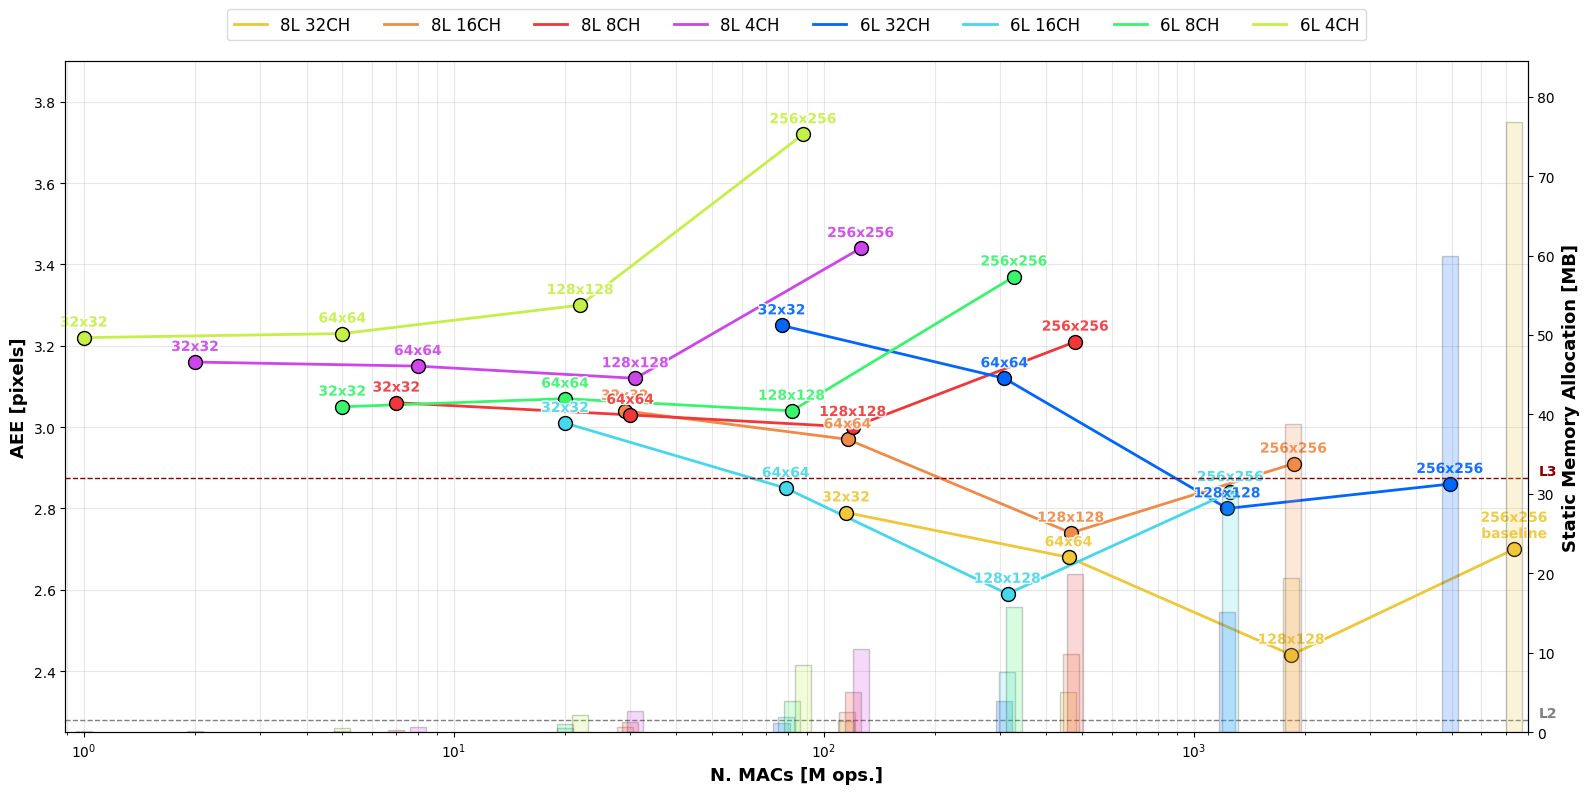

Total groups with data: 8
8L 32CH: 4 points
8L 16CH: 4 points
8L 8CH: 4 points
8L 4CH: 4 points
6L 32CH: 4 points
6L 16CH: 4 points
6L 8CH: 4 points
6L 4CH: 4 points


In [53]:
# CURVES BASED ON SPECIFIC MODELS BASED ON INPUT RESOLUTION (MODULUS ERROR):
# 8 curves: FN/FNs with each channel count (32ch, 16ch, 8ch, 4ch) across all resolutions

import matplotlib.lines as mlines
from matplotlib.patheffects import withStroke

data_type = 'float32'  # 'float32' or 'int8'

# Filter out rows with None Runtime values and exclude baseline
if data_type == 'float32':
    df_filtered = df_full[(df_full['N. MACs [M ops.]'].notna()) & (df_full['Model'] != 'baseline')].copy()
else:
    df_filtered = df_full_int8[(df_full_int8['N. MACs [M ops.]'].notna()) & (df_full_int8['Model'] != 'baseline')].copy()

# Filter out rows with None Runtime values and exclude baseline
df_filtered = df_full[(df_full['N. MACs [M ops.]'].notna()) & (df_full['Model'] != 'baseline')].copy()

# Extract layer type, channel, and resolution information
# IMPORTANT: Check for 'FNs' first, then 'FN' to avoid misclassification
df_filtered['Layer_Type'] = df_filtered['Model'].str.extract(r'^(6L|8L)\b')[0]
df_filtered['Channels'] = df_filtered['Model'].str.extract(r'(\d+)CH')[0].astype(int)
df_filtered['Resolution'] = df_filtered['Model'].str.extract(r'(\d+x\d+)')[0]

# Create labels showing only resolution (what varies along each curve)
df_filtered['Label'] = df_filtered['Resolution']

# Group by layer type and channel count
layer_channel_groups = {}
for layer_type in ['8L', '6L']:
    for ch in [32, 16, 8, 4]:
        key = f'{layer_type} {ch}CH'
        group_data = df_filtered[
            (df_filtered['Layer_Type'] == layer_type) & 
            (df_filtered['Channels'] == ch)
        ].copy()
        # Only add groups that have data
        if len(group_data) > 0:
            layer_channel_groups[key] = group_data

# Create figure
fig, ax1 = plt.subplots(figsize=(16, 8))
ax1.set_facecolor('none')
fig.patch.set_alpha(0.0)

# Axes labels and limits
ax1.set_xlabel('N. MACs [M ops.]', fontsize=13, fontweight='bold')
ax1.set_ylabel('AEE [pixels]', fontsize=13, fontweight='bold')
ax1.set_xscale('log')
ax1.set_xlim(0, 8000)
ax1.set_ylim(2.25, 3.9)
ax1.grid(True, alpha=0.3, which='both')

# Second y axis for memory
ax2 = ax1.twinx()
ax2.set_ylabel('Static Memory Allocation [MB]', fontsize=13, fontweight='bold', labelpad=5)
ax2.set_ylim(0, max(df_filtered['Static Memory Allocation [MB]']) * 1.1)

# Define colors for the eight groups (using a diverse color palette)
colors = {
    '8L 32CH': '#EFC737',    
    '8L 16CH': '#F08B47',   
    '8L 8CH': '#F03739',     
    '8L 4CH': '#CE45EB',     
    '6L 32CH': '#0066FF',   
    '6L 16CH': '#47D7EA',   
    '6L 8CH': '#38F56D',    
    '6L 4CH': '#C5F048'     
}

# Manual label offset dictionary
# Key: (group_name, resolution), Value: (x_offset, y_offset)
label_offsets = {
    # Add your custom offsets here
    # ('group_name', 'resolution'): (x_offset, y_offset)
    
}

def get_label_offset(group_name, resolution):
    return label_offsets.get((group_name, resolution), (0, 8))  # Default offset

# Plot memory bars for each group
bar_width_factor = 0.10
offset_start = 0.85
offset_step = 0.04
offset_factors = {key: offset_start + i * offset_step for i, key in enumerate(layer_channel_groups.keys())}

for group_name, df_group in layer_channel_groups.items():
    for idx, row in df_group.iterrows():
        bar_width = row['N. MACs [M ops.]'] * bar_width_factor
        ax2.bar(row['N. MACs [M ops.]'], 
               row['Static Memory Allocation [MB]'],
               width=bar_width, color=colors[group_name], alpha=0.2, align='center', 
               zorder=5, edgecolor='black', linewidth=1.0)

# Add horizontal lines for static memory allocation
ax2.axhline(y=1.5, color='gray', linestyle='--', linewidth=1, zorder=1)
ax2.axhline(y=32, color='darkred', linestyle='--', linewidth=1, zorder=1)
ax2.text(ax2.get_xlim()[1] * 1.2, 1.5, 'L2', color='gray', fontsize=10, fontweight='bold', verticalalignment='bottom', horizontalalignment='right')
ax2.text(ax2.get_xlim()[1] * 1.2, 32, 'L3', color='darkred', fontsize=10, fontweight='bold', verticalalignment='bottom', horizontalalignment='right')

# Plot curves for each group
for group_name, df_group in layer_channel_groups.items():
    # Sort by runtime
    df_group_sorted = df_group.sort_values('N. MACs [M ops.]')
    
    # Plot line
    ax1.plot(df_group_sorted['N. MACs [M ops.]'], df_group_sorted['AEE [pixels]'], 
            linestyle='-', color=colors[group_name], linewidth=2, label=group_name, zorder=2)
    
    # Plot scatter points
    ax1.scatter(df_group_sorted['N. MACs [M ops.]'], df_group_sorted['AEE [pixels]'], 
               color=colors[group_name], s=100, edgecolor='black', zorder=3)
    
    # Add labels for each point (showing only resolution)
    for idx, row in df_group_sorted.iterrows():
        # Add 'baseline' to the label for 8L 32CH 256x256
        if group_name == '8L 32CH' and row['Label'] == '256x256':
            label_text = f"\nbaseline"
        else:
            label_text = f""
        offset_x, offset_y = get_label_offset(group_name, row['Label'])
        ax1.annotate(f"{row['Label']}{label_text}",  
                    (row['N. MACs [M ops.]'], row['AEE [pixels]']), 
                    textcoords="offset points", xytext=(offset_x, offset_y), ha='center', 
                    fontsize=10, color=colors[group_name], fontweight='bold', alpha=0.9, zorder=11,
                    path_effects=[withStroke(linewidth=2, foreground='white')])

legend = ax1.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 1.09), ncol=8, 
                   frameon=True, fancybox=True, shadow=False, 
                   facecolor='white', edgecolor='lightgray', framealpha=0.8)

fig.tight_layout()
plt.show()

# Print summary
print(f"Total groups with data: {len(layer_channel_groups)}")
for group_name, df_group in layer_channel_groups.items():
    print(f"{group_name}: {len(df_group)} points")

THROUGHPUT ESTIMATION FOR: 8L 256x256 32CH FP32

Model specifications:
  - Layers: 8L
  - Resolution: 256x256
  - Channels: 32CH
  - Operations: 7350 M MAC
  - Static Memory: 76.8 MB (requires L3)
  - Dynamic Memory: 75.5 MB

Method                                   Estimated Throughput
------------------------------------------------------------
1. Power-law regression (all models)     0.026 Hz
2. Power-law regression (8L models only) 0.023 Hz
3. Runtime-based (scaled from 8L 256x256 8CH) 0.025 Hz
4. Scaled from 6L 256x256 32CH           N/A (no data)       
------------------------------------------------------------
RECOMMENDED ESTIMATE (average)           0.025 Hz
RECOMMENDED ESTIMATE (range)             0.023 - 0.026 Hz

REGRESSION ANALYSIS DETAILS

Power-law model (all FP32 models): Throughput = k × (Operations)^α
  - Coefficient (k): 114.613473
  - Exponent (α): -0.943713
  - R² score: 0.8324

Power-law model (8L models only): Throughput = k × (Operations)^α
  - Coefficient (k):

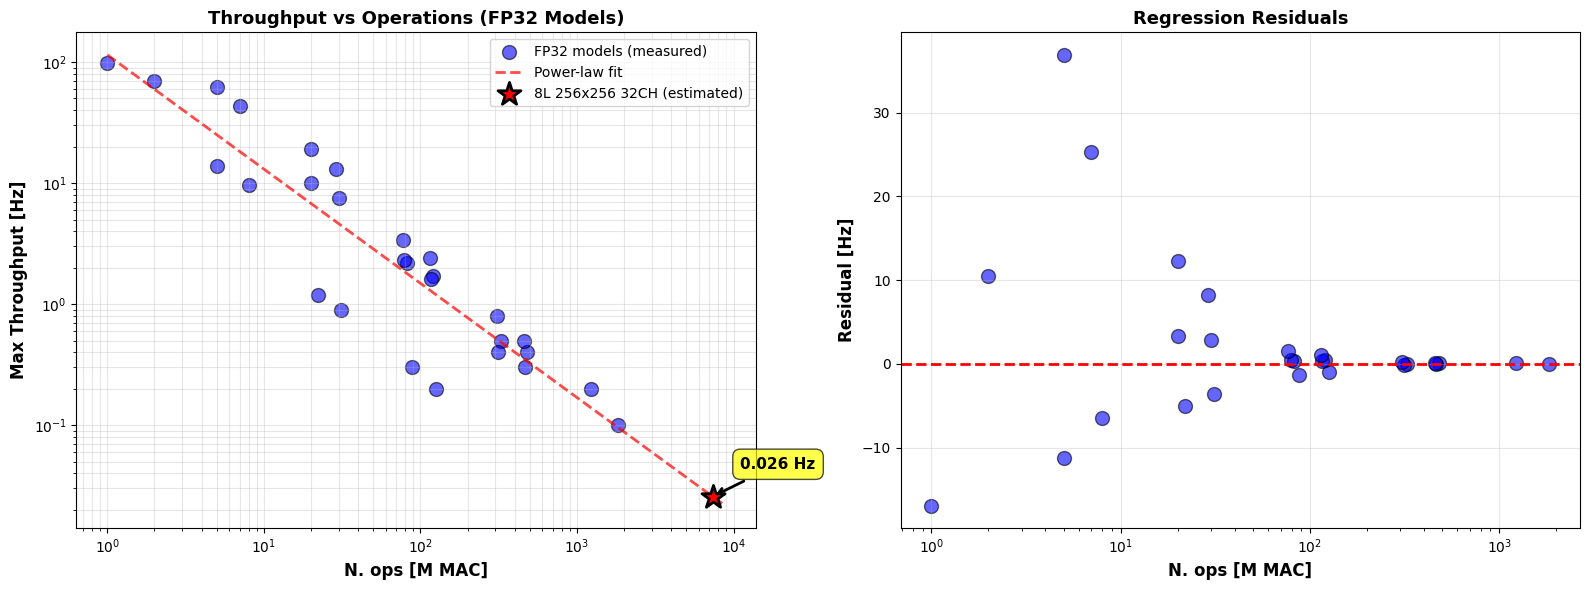


COMPARISON WITH MEASURED MODELS

Model                     N. ops [M MAC]  Measured [Hz]   Ratio to Target
----------------------------------------------------------------------
8L 128x128 32CH           1838            0.10            3.89           x
6L 128x128 32CH           1233            0.20            7.77           x
8L 256x256 8CH            479             0.40            15.54          x
8L 64x64 32CH             459             0.50            19.43          x
6L 256x256 8CH            327             0.50            19.43          x
6L 64x64 32CH             308             0.80            31.08          x
8L 256x256 4CH            126             0.20            7.77           x
8L 32x32 32CH             115             2.40            93.25          x
6L 256x256 4CH            88              0.30            11.66          x
6L 32x32 32CH             77              3.40            132.10         x

FINAL RECOMMENDATION: 0.025 Hz (±0.001 Hz)


In [47]:
# Throughput Estimation for 8L 256x256 32CH FP32 Model
# Using regression analysis on available data

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create dataframe from FP32 data
df_fp32 = pd.DataFrame(FULL_DATASET)

# Filter only models with valid throughput data
df_analysis = df_fp32[df_fp32['Max Throughput [Hz] at 370 MHz'].notna()].copy()

# The key insight: Throughput is inversely related to operations
# Throughput ≈ Clock_Frequency / Runtime
# Runtime ≈ Operations × Cycles_per_Operation

# Method 1: Direct relationship between throughput and operations
# Assuming: Throughput [Hz] = k / N_ops [M MAC]
df_analysis['Inverse_Ops'] = 1 / df_analysis['N. ops [M MAC]']

X = df_analysis[['N. ops [M MAC]']].values
y = df_analysis['Max Throughput [Hz] at 370 MHz'].values

# Log-log regression (power law relationship)
X_log = np.log10(X)
y_log = np.log10(y)

model_log = LinearRegression()
model_log.fit(X_log, y_log)

# Predict for target model
target_ops = 7350  # M MAC for 8L 256x256 32CH
target_ops_log = np.log10([[target_ops]])
predicted_throughput_log = 10 ** model_log.predict(target_ops_log)[0]

print("=" * 80)
print("THROUGHPUT ESTIMATION FOR: 8L 256x256 32CH FP32")
print("=" * 80)
print(f"\nModel specifications:")
print(f"  - Layers: 8L")
print(f"  - Resolution: 256x256")
print(f"  - Channels: 32CH")
print(f"  - Operations: {target_ops} M MAC")
print(f"  - Static Memory: 76.8 MB (requires L3)")
print(f"  - Dynamic Memory: 75.5 MB")

print(f"\n{'Method':<40} {'Estimated Throughput':<20}")
print("-" * 60)

# Method 1: Log-log regression (power law)
print(f"{'1. Power-law regression (all models)':<40} {predicted_throughput_log:.3f} Hz")

# Method 2: Compare with similar 8L models
df_8L = df_analysis[df_analysis['Model'].str.startswith('8L')].copy()
# Fit only on 8L models
X_8L_log = np.log10(df_8L[['N. ops [M MAC]']].values)
y_8L_log = np.log10(df_8L['Max Throughput [Hz] at 370 MHz'].values)
model_8L = LinearRegression()
model_8L.fit(X_8L_log, y_8L_log)
predicted_8L = 10 ** model_8L.predict(target_ops_log)[0]
print(f"{'2. Power-law regression (8L models only)':<40} {predicted_8L:.3f} Hz")

# Method 3: Using Runtime data
# For models with runtime: Throughput = 370 MHz / Runtime
df_runtime = df_fp32[df_fp32['Runtime [M cycles]'].notna()].copy()
# Estimate runtime for target based on operations ratio
similar_model = df_runtime[df_runtime['Model'] == '8L 256x256 8CH'].iloc[0]
ops_ratio = target_ops / similar_model['N. ops [M MAC]']
estimated_runtime = similar_model['Runtime [M cycles]'] * ops_ratio
estimated_throughput_runtime = 370 / estimated_runtime
print(f"{'3. Runtime-based (scaled from 8L 256x256 8CH)':<40} {estimated_throughput_runtime:.3f} Hz")

# Method 4: Check 6L 256x256 32CH as reference (same res, same channels, different layers)
model_6L_32CH = df_fp32[df_fp32['Model'] == '6L 256x256 32CH'].iloc[0]
if pd.notna(model_6L_32CH['Max Throughput [Hz] at 370 MHz']):
    ratio_6L = model_6L_32CH['Max Throughput [Hz] at 370 MHz']
    # Scale by operations ratio
    ops_ratio_6L = model_6L_32CH['N. ops [M MAC]'] / target_ops
    estimated_from_6L = ratio_6L * ops_ratio_6L
    print(f"{'4. Scaled from 6L 256x256 32CH':<40} {estimated_from_6L:.3f} Hz")
else:
    print(f"{'4. Scaled from 6L 256x256 32CH':<40} {'N/A (no data)':<20}")

# Method 5: Weighted average of methods
valid_estimates = [predicted_throughput_log, predicted_8L, estimated_throughput_runtime]
weighted_avg = np.mean(valid_estimates)
print("-" * 60)
print(f"{'RECOMMENDED ESTIMATE (average)':<40} {weighted_avg:.3f} Hz")
print(f"{'RECOMMENDED ESTIMATE (range)':<40} {min(valid_estimates):.3f} - {max(valid_estimates):.3f} Hz")

print("\n" + "=" * 80)
print("REGRESSION ANALYSIS DETAILS")
print("=" * 80)
print(f"\nPower-law model (all FP32 models): Throughput = k × (Operations)^α")
print(f"  - Coefficient (k): {10**model_log.intercept_:.6f}")
print(f"  - Exponent (α): {model_log.coef_[0]:.6f}")
print(f"  - R² score: {model_log.score(X_log, y_log):.4f}")

print(f"\nPower-law model (8L models only): Throughput = k × (Operations)^α")
print(f"  - Coefficient (k): {10**model_8L.intercept_:.6f}")
print(f"  - Exponent (α): {model_8L.coef_[0]:.6f}")
print(f"  - R² score: {model_8L.score(X_8L_log, y_8L_log):.4f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_alpha(0.0)
ax1.set_facecolor('none')
ax2.set_facecolor('none')

# Plot 1: All models with regression line
ax1.scatter(df_analysis['N. ops [M MAC]'], 
           df_analysis['Max Throughput [Hz] at 370 MHz'],
           s=100, alpha=0.6, label='FP32 models (measured)', c='blue', edgecolors='black')

# Regression line
ops_range = np.logspace(np.log10(df_analysis['N. ops [M MAC]'].min()), 
                        np.log10(target_ops * 1.2), 100)
throughput_pred = 10 ** model_log.predict(np.log10(ops_range.reshape(-1, 1)))

ax1.plot(ops_range, throughput_pred, 'r--', linewidth=2, label='Power-law fit', alpha=0.7)
ax1.scatter([target_ops], [predicted_throughput_log], s=300, c='red', marker='*', 
           edgecolors='black', linewidth=2, zorder=5, label='8L 256x256 32CH (estimated)')

ax1.set_xlabel('N. ops [M MAC]', fontsize=12, fontweight='bold')
ax1.set_ylabel('Max Throughput [Hz]', fontsize=12, fontweight='bold')
ax1.set_title('Throughput vs Operations (FP32 Models)', fontsize=13, fontweight='bold')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=10)

# Add annotation for target
ax1.annotate(f'{predicted_throughput_log:.3f} Hz',
            (target_ops, predicted_throughput_log),
            textcoords="offset points", xytext=(20, 20),
            ha='left', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', lw=2))

# Plot 2: Residuals
predicted_all = 10 ** model_log.predict(X_log)
residuals = y - predicted_all
ax2.scatter(df_analysis['N. ops [M MAC]'], residuals, s=100, alpha=0.6, 
           c='blue', edgecolors='black')
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('N. ops [M MAC]', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residual [Hz]', fontsize=12, fontweight='bold')
ax2.set_title('Regression Residuals', fontsize=13, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("COMPARISON WITH MEASURED MODELS")
print("=" * 80)
print(f"\n{'Model':<25} {'N. ops [M MAC]':<15} {'Measured [Hz]':<15} {'Ratio to Target':<15}")
print("-" * 70)

# Show similar models for context
similar_models = df_analysis[
    (df_analysis['Model'].str.contains('256x256')) | 
    (df_analysis['Model'].str.contains('32CH'))
].sort_values('N. ops [M MAC]', ascending=False)

for _, row in similar_models.head(10).iterrows():
    ratio = row['Max Throughput [Hz] at 370 MHz'] / predicted_throughput_log
    print(f"{row['Model']:<25} {row['N. ops [M MAC]']:<15.0f} {row['Max Throughput [Hz] at 370 MHz']:<15.2f} {ratio:<15.2f}x")

print("\n" + "=" * 80)
print(f"FINAL RECOMMENDATION: {weighted_avg:.3f} Hz (±{(max(valid_estimates)-min(valid_estimates))/2:.3f} Hz)")
print("=" * 80)